# Aproximacion Gaussiana de Curvas — Suma de Campanas y Splines

El notebook 01 mostro que una sola campana gaussiana alcanza un R² medio de 0.74 sobre las 500 curvas,
con apenas 36 curvas superando R² = 0.99. El modelo era demasiado simple

En este notebook extendemos la aproximacion en dos direcciones:

1. **Suma de gaussianas**: el mismo modelo de campana, repetido N veces. Cada campana cubre una region
   de la curva. La clave es decidir cuantas campanas usar y donde colocarlas.

2. **Splines**: una familia diferente de modelos que usan polinomios locales empalmados en puntos llamados
   nudos. Son mas flexibles y sistematicamente mas precisos, aunque menos interpretables.

Al final comparamos ambos metodos en las 500 curvas para entender sus fortalezas y limitaciones.


## 1. Configuracion e imports

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.interpolate import UnivariateSpline, CubicSpline
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 100})

TARGET_DIR = Path('../..') / 'datos' / 'target'

PALETA = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0',
          '#00BCD4', '#FF5722', '#607D8B']

def cargar_curva(curve_id):
    path = TARGET_DIR / f'curve_{curve_id:04d}.txt'
    data = np.loadtxt(path, delimiter=',')
    return data[:, 0], data[:, 1]

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


## 2. Distribucion de picos en el dataset

Antes de ajustar modelos, conviene entender cuantos picos tienen las curvas.
Esto determina directamente cuantas campanas gaussianas son necesarias.

Usamos `scipy.signal.find_peaks` con un umbral de prominencia del 5% del rango vertical.
La prominencia mide cuanto sobresale un pico respecto a su vecindad, filtrando ruido menor.

In [24]:
def contar_picos(x, y, prominence_frac=0.05, distance=50):
    """Cuenta picos y valles con prominencia relativa al rango de Y."""
    rango = y.max() - y.min()
    prom = prominence_frac * rango
    peaks, props_p = find_peaks(y, prominence=prom, distance=distance)
    valleys, props_v = find_peaks(-y, prominence=prom, distance=distance)
    return peaks, valleys, props_p, props_v

registros_picos = []
for cid in range(1, 501):
    x, y = cargar_curva(cid)
    xs, ys = x[::8], y[::8]  # ~1000 puntos por curva
    peaks, valleys, _, _ = contar_picos(xs, ys)
    registros_picos.append({
        'curva': cid,
        'n_picos': len(peaks),
        'n_valles': len(valleys),
        'rango_y': float(ys.max() - ys.min()),
        'rango_x': float(xs.max() - xs.min()),
    })

df_picos = pd.DataFrame(registros_picos)
print('Distribucion de numero de picos (prominence >= 5% del rango Y):')
print(df_picos['n_picos'].value_counts().sort_index().to_string())
print(f'\nTotal curvas analizadas: {len(df_picos)}')

Distribucion de numero de picos (prominence >= 5% del rango Y):
n_picos
0     51
1    183
2    150
3     98
4     18

Total curvas analizadas: 500


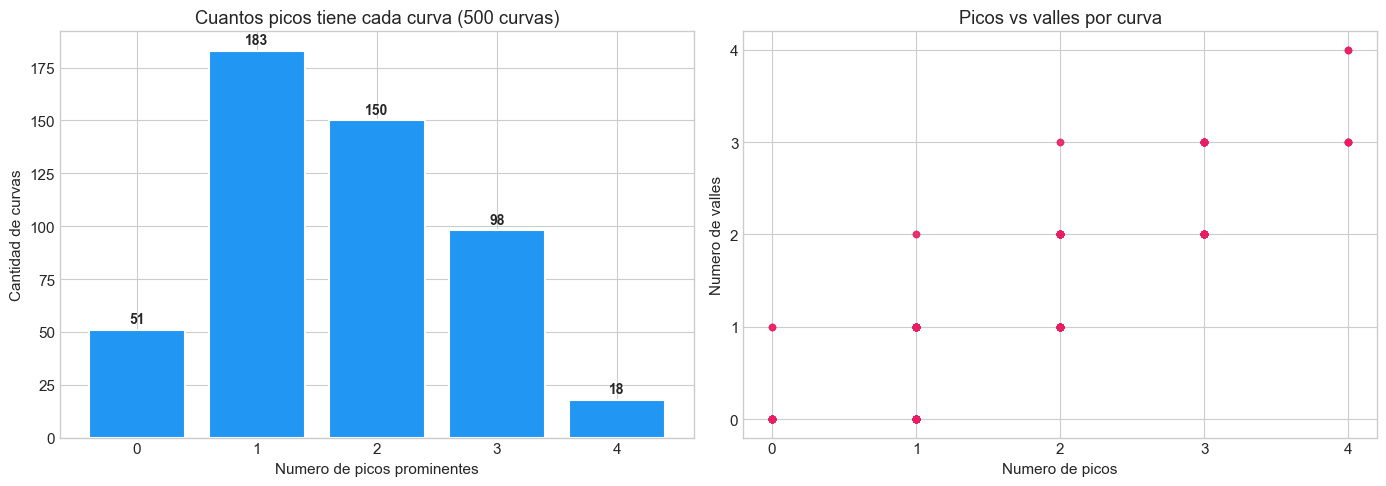

Interpretacion:
  - La mayoria de curvas tiene entre 1 y 3 picos.
  - Las que tienen 0 picos son curvas monotonas (siempre crecen o decrecen).
  - El numero de picos guia directamente cuantas campanas necesitamos.


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribucion de picos
conteos = df_picos['n_picos'].value_counts().sort_index()
axes[0].bar(conteos.index, conteos.values, color='#2196F3', edgecolor='white', lw=1.5)
for xi, vi in zip(conteos.index, conteos.values):
    axes[0].text(xi, vi + 3, str(vi), ha='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Numero de picos prominentes')
axes[0].set_ylabel('Cantidad de curvas')
axes[0].set_title('Cuantos picos tiene cada curva (500 curvas)')
axes[0].set_xticks(conteos.index)

# Picos vs valles
axes[1].scatter(df_picos['n_picos'], df_picos['n_valles'],
                alpha=0.4, s=20, color='#E91E63')
axes[1].set_xlabel('Numero de picos')
axes[1].set_ylabel('Numero de valles')
axes[1].set_title('Picos vs valles por curva')
axes[1].set_xticks([0, 1, 2, 3, 4])
axes[1].set_yticks([0, 1, 2, 3, 4])

plt.tight_layout()
plt.show()

print('Interpretacion:')
print('  - La mayoria de curvas tiene entre 1 y 3 picos.')
print('  - Las que tienen 0 picos son curvas monotonas (siempre crecen o decrecen).')
print('  - El numero de picos guia directamente cuantas campanas necesitamos.')

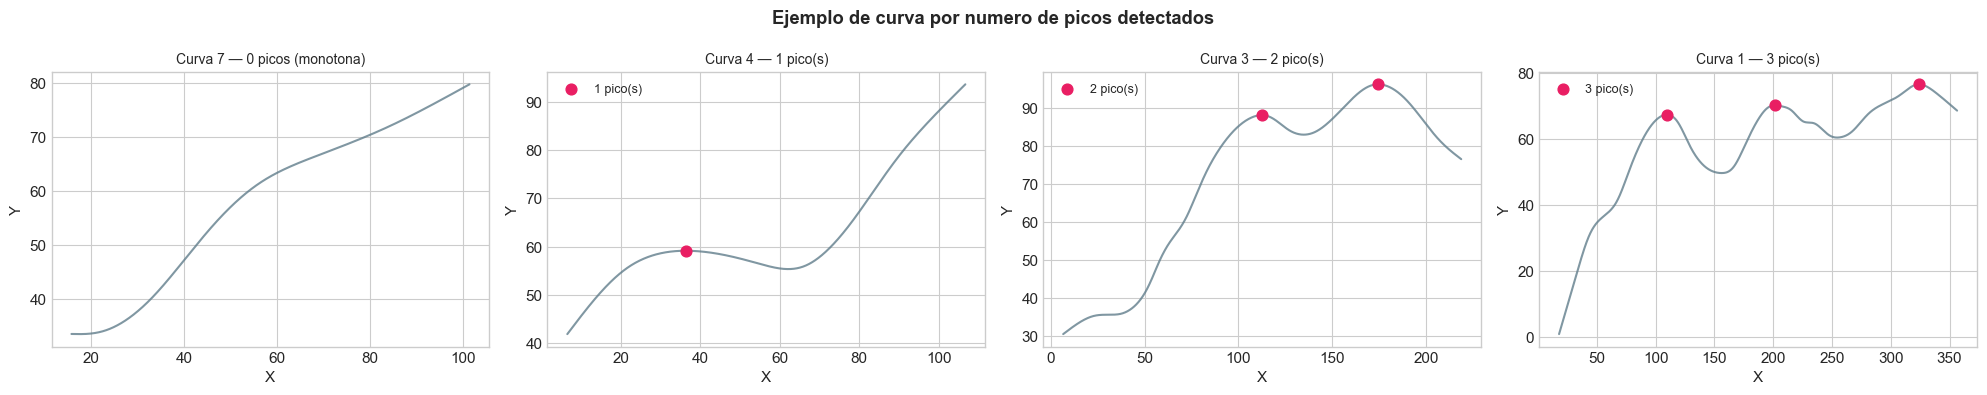

In [26]:
# Visualizar ejemplos de cada tipo
ejemplos_por_tipo = {}
for n in [0, 1, 2, 3]:
    candidatos = df_picos[df_picos['n_picos'] == n]['curva'].values
    if len(candidatos) > 0:
        ejemplos_por_tipo[n] = int(candidatos[0])

fig, axes = plt.subplots(1, len(ejemplos_por_tipo), figsize=(5 * len(ejemplos_por_tipo), 4))

for idx, (n_picos, cid) in enumerate(sorted(ejemplos_por_tipo.items())):
    ax = axes[idx]
    x, y = cargar_curva(cid)
    xs, ys = x[::8], y[::8]
    peaks, _, _, _ = contar_picos(xs, ys)

    ax.plot(xs, ys, color='#607D8B', lw=1.5, alpha=0.8)
    if len(peaks) > 0:
        ax.scatter(xs[peaks], ys[peaks], color='#E91E63', s=60, zorder=5,
                   label=f'{len(peaks)} pico(s)')
        ax.legend(fontsize=9)

    label = '0 picos (monotona)' if n_picos == 0 else f'{n_picos} pico(s)'
    ax.set_title(f'Curva {cid} — {label}', fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.suptitle('Ejemplo de curva por numero de picos detectados', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Modelo: suma de gaussianas

El modelo de una sola campana del notebook 01 era:

$$y = A \cdot e^{-\frac{(x - \mu)^2}{2\sigma^2}} + c$$

La extension natural es sumar N campanas independientes, cada una con sus propios parametros de amplitud,
posicion y ancho:

$$y = c + \sum_{i=1}^{N} A_i \cdot e^{-\frac{(x - \mu_i)^2}{2\sigma_i^2}}$$

Parametros del modelo:

| Simbolo | Significado | Restriccion |
|---------|-------------|-------------|
| $c$ | linea base global | libre |
| $A_i$ | amplitud de la campana i | $A_i > 0$ |
| $\mu_i$ | centro de la campana i | $x_{min} \leq \mu_i \leq x_{max}$ |
| $\sigma_i$ | ancho de la campana i | $\sigma_i > 0$ |

El total de parametros para N campanas es $1 + 3N$.

El ajuste se realiza por minimos cuadrados no lineales con `scipy.optimize.curve_fit`,
igual que en el notebook 01. La diferencia es que ahora el espacio de busqueda es mayor
y la inicializacion de los parametros se vuelve critica.

In [27]:
def suma_gaussianas(x, *params):
    """
    Modelo: y = c + sum_i A_i * exp(-((x - mu_i)^2) / (2*sigma_i^2))

    params = [c, A1, mu1, sigma1, A2, mu2, sigma2, ...]
    """
    c = params[0]
    result = np.full_like(x, c, dtype=float)
    n = (len(params) - 1) // 3
    for i in range(n):
        A   = params[1 + 3*i]
        mu  = params[2 + 3*i]
        sig = params[3 + 3*i]
        result += A * np.exp(-((x - mu)**2) / (2 * sig**2))
    return result


def construir_p0_bounds(xs, ys, mu_locs):
    """
    Construye p0 y bounds para un ajuste con campanas centradas en mu_locs.
    mu_locs puede ser array de posiciones en X.
    """
    n = len(mu_locs)
    rango_x = float(xs.max() - xs.min())
    rango_y = float(ys.max() - ys.min())
    c0 = float(ys.min())

    p0 = [c0]
    blo = [c0 - rango_y - 1]
    bhi = [float(ys.max())]

    for mu0 in mu_locs:
        idx_near = int(np.argmin(np.abs(xs - mu0)))
        A0 = max(float(ys[idx_near] - c0), 0.1)
        s0 = rango_x / (3.0 * n)
        p0  += [A0, float(mu0), s0]
        blo += [0.0,         float(xs.min()), 0.5]
        bhi += [A0 * 5 + 1,  float(xs.max()), rango_x]

    return p0, blo, bhi


def ajustar_suma_gaussianas(xs, ys, mu_locs, maxfev=80000):
    """Ajusta la suma de gaussianas con campanas en mu_locs. Devuelve dict con resultados."""
    p0, blo, bhi = construir_p0_bounds(xs, ys, mu_locs)
    try:
        popt, pcov = curve_fit(
            suma_gaussianas, xs, ys,
            p0=p0, bounds=(blo, bhi),
            maxfev=maxfev, method='trf'
        )
        y_pred = suma_gaussianas(xs, *popt)
        return {
            'exito': True,
            'popt': popt,
            'y_pred': y_pred,
            'r2': float(r2_score(ys, y_pred)),
            'rmse': rmse(ys, y_pred),
            'n_campanas': len(mu_locs),
        }
    except Exception as e:
        return {'exito': False, 'error': str(e), 'n_campanas': len(mu_locs)}


print('Funciones del modelo definidas.')
print(f'  suma_gaussianas con N campanas usa 1 + 3*N parametros.')
for n in [1, 2, 3, 5, 8]:
    print(f'  N={n}: {1 + 3*n} parametros')

Funciones del modelo definidas.
  suma_gaussianas con N campanas usa 1 + 3*N parametros.
  N=1: 4 parametros
  N=2: 7 parametros
  N=3: 10 parametros
  N=5: 16 parametros
  N=8: 25 parametros


## 4. Estrategia de inicializacion automatica

El ajuste por minimos cuadrados no lineales es sensible a los valores iniciales.
Con una sola gaussiana, el truco es usar la posicion del maximo como estimacion de mu.
Con N campanas, necesitamos una estrategia mas sistematica.

Usamos dos estrategias:

**Estrategia A: Deteccion de picos**
- Detectar picos en los datos con `find_peaks`.
- Colocar una campana centrada en cada pico detectado.
- Funciona bien cuando los picos son visibles y separados.

**Estrategia B: Distribucion uniforme**
- Colocar N campanas igualmente espaciadas en el rango de X.
- No requiere detectar picos; funciona incluso en curvas sin picos claros.
- Con N suficientemente grande, puede aproximar cualquier forma suave.

Comparamos ambas estrategias a continuacion.

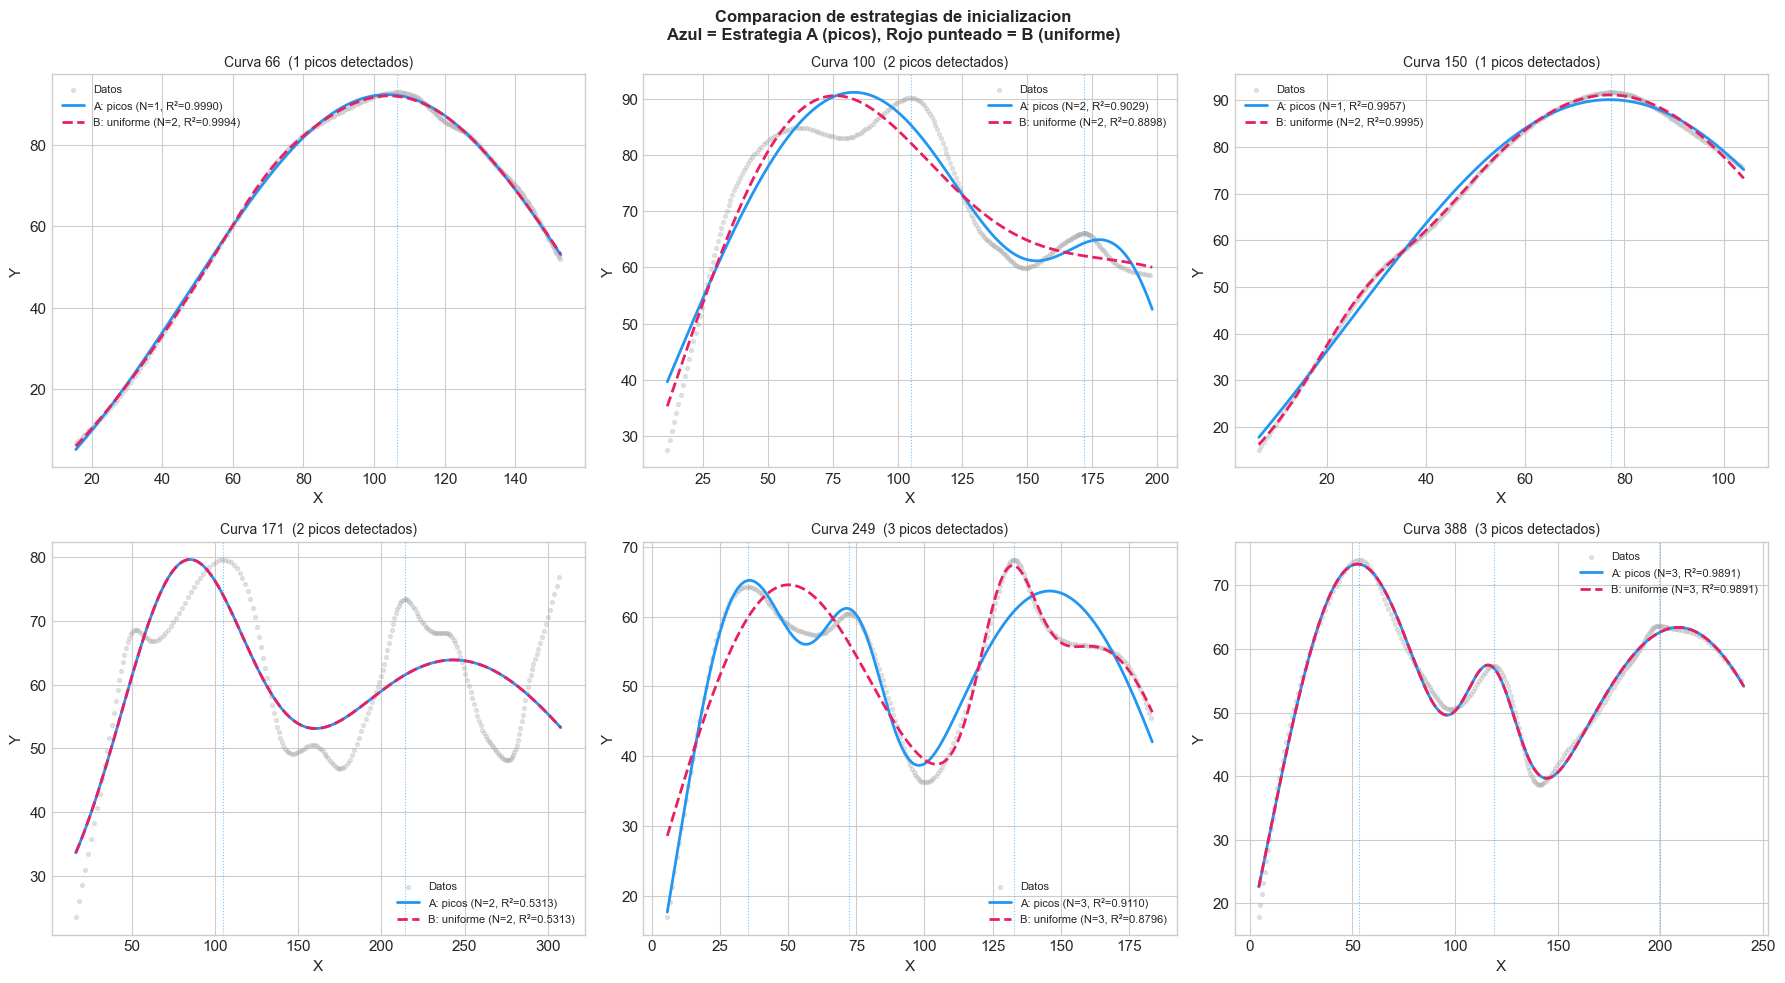

Tabla comparativa:
 curva  n_picos  r2_estrategia_A  r2_estrategia_B
    66        1         0.999002         0.999357
   100        2         0.902896         0.889819
   150        1         0.995721         0.999511
   171        2         0.531299         0.531299
   249        3         0.911011         0.879602
   388        3         0.989076         0.989076


In [28]:
def mu_locs_por_picos(xs, ys, prominence_frac=0.05):
    """Detecta picos y devuelve sus posiciones en X. Si no hay, usa el maximo."""
    rango = ys.max() - ys.min()
    peaks, _ = find_peaks(ys, prominence=prominence_frac * rango, distance=20)
    if len(peaks) == 0:
        peaks = np.array([int(np.argmax(ys))])
    return xs[peaks]


def mu_locs_uniformes(xs, n):
    """N posiciones igualmente espaciadas, excluyendo los extremos."""
    margin = (xs.max() - xs.min()) * 0.05
    return np.linspace(xs.min() + margin, xs.max() - margin, n)


# Comparar ambas estrategias en 6 curvas representativas
curvas_demo = [66, 100, 150, 171, 249, 388]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

comparativa_estrategias = []

for idx, cid in enumerate(curvas_demo):
    ax = axes[idx]
    x, y = cargar_curva(cid)
    xs, ys = x[::8], y[::8]

    ax.scatter(xs[::4], ys[::4], s=8, alpha=0.3, color='#aaaaaa',
               label='Datos', zorder=1)

    # Estrategia A: picos
    mu_a = mu_locs_por_picos(xs, ys)
    res_a = ajustar_suma_gaussianas(xs, ys, mu_a)
    if res_a['exito']:
        ax.plot(xs, res_a['y_pred'], color='#2196F3', lw=2,
                label=f"A: picos (N={len(mu_a)}, R²={res_a['r2']:.4f})", zorder=3)
    for mu in mu_a:
        ax.axvline(mu, color='#2196F3', lw=0.8, linestyle=':', alpha=0.6)

    # Estrategia B: uniforme con el mismo N
    n_unif = max(len(mu_a), 2)
    mu_b = mu_locs_uniformes(xs, n_unif)
    res_b = ajustar_suma_gaussianas(xs, ys, mu_b)
    if res_b['exito']:
        ax.plot(xs, res_b['y_pred'], color='#E91E63', lw=2, linestyle='--',
                label=f"B: uniforme (N={n_unif}, R²={res_b['r2']:.4f})", zorder=3)

    n_picos = len(mu_locs_por_picos(xs, ys))
    ax.set_title(f'Curva {cid}  ({n_picos} picos detectados)', fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(fontsize=8, loc='best')

    comparativa_estrategias.append({
        'curva': cid,
        'n_picos': n_picos,
        'r2_estrategia_A': res_a.get('r2', np.nan),
        'r2_estrategia_B': res_b.get('r2', np.nan),
    })

plt.suptitle('Comparacion de estrategias de inicializacion\nAzul = Estrategia A (picos), Rojo punteado = B (uniforme)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

df_strat = pd.DataFrame(comparativa_estrategias)
print('Tabla comparativa:')
print(df_strat.to_string(index=False))

## 5. Efecto del numero de campanas N

Con la estrategia de distribucion uniforme, podemos probar sistematicamente que pasa
cuando aumentamos N desde 1 hasta 8. Esto nos dice cuantas campanas necesita cada curva
para alcanzar un ajuste aceptable.

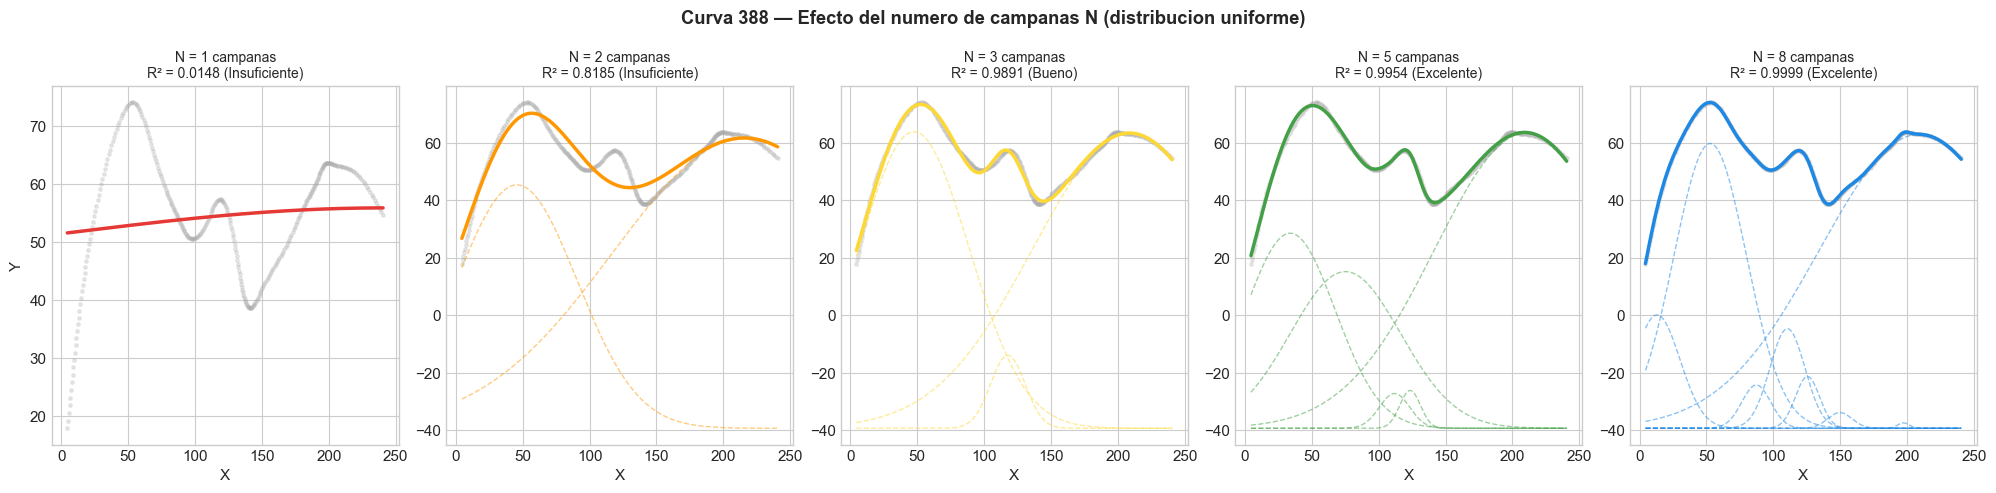

La linea continua es el ajuste total. Las lineas punteadas son cada campana individualmente.
Con N pequeno, las campanas no tienen suficiente libertad para cubrir toda la forma.
Con N suficiente, el ajuste cubre todos los picos y la linea base.


In [29]:
# Mostrar visualmente el efecto de N en una curva compleja
CID_DEMO = 388  # curva con 3 picos, R² bajo en notebook 01
x, y = cargar_curva(CID_DEMO)
xs, ys = x[::8], y[::8]

ns_a_probar = [1, 2, 3, 5, 8]
colores_n = ['#E53935', '#FF9800', '#FDD835', '#43A047', '#1E88E5']

fig, axes = plt.subplots(1, len(ns_a_probar), figsize=(20, 5))

for idx, (n, col) in enumerate(zip(ns_a_probar, colores_n)):
    ax = axes[idx]
    mu_locs = mu_locs_uniformes(xs, n)
    res = ajustar_suma_gaussianas(xs, ys, mu_locs)

    ax.scatter(xs[::3], ys[::3], s=6, alpha=0.25, color='#aaaaaa', zorder=1)

    if res['exito']:
        ax.plot(xs, res['y_pred'], color=col, lw=2.5, zorder=3,
                label=f"R²={res['r2']:.4f}")
        # mostrar cada campana individual
        popt = res['popt']
        c_base = popt[0]
        x_dense = np.linspace(xs.min(), xs.max(), 500)
        for i in range(n):
            A_i, mu_i, s_i = popt[1+3*i], popt[2+3*i], popt[3+3*i]
            campana_i = c_base + A_i * np.exp(-((x_dense - mu_i)**2) / (2*s_i**2))
            ax.plot(x_dense, campana_i, lw=1, linestyle='--', alpha=0.5, color=col)

        titulo_r2 = f"R² = {res['r2']:.4f}"
        if res['r2'] < 0.85:
            calidad = 'Insuficiente'
        elif res['r2'] < 0.95:
            calidad = 'Aceptable'
        elif res['r2'] < 0.99:
            calidad = 'Bueno'
        else:
            calidad = 'Excelente'
        ax.set_title(f'N = {n} campanas\n{titulo_r2} ({calidad})', fontsize=10)
    else:
        ax.set_title(f'N = {n}\nFallo')

    ax.set_xlabel('X')
    if idx == 0:
        ax.set_ylabel('Y')

plt.suptitle(f'Curva {CID_DEMO} — Efecto del numero de campanas N (distribucion uniforme)',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('La linea continua es el ajuste total. Las lineas punteadas son cada campana individualmente.')
print('Con N pequeno, las campanas no tienen suficiente libertad para cubrir toda la forma.')
print('Con N suficiente, el ajuste cubre todos los picos y la linea base.')

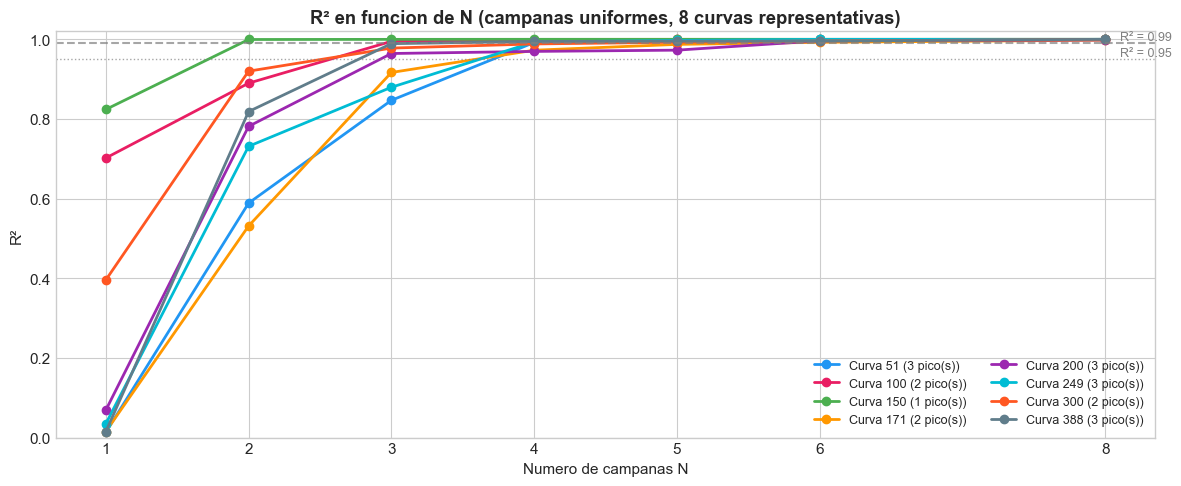

Observaciones:
  - Casi todas las curvas alcanzan R² > 0.99 con N = 5 a 8 campanas.
  - El salto mas grande suele ocurrir al pasar de N=1 a N=2 o N=3.
  - Curvas con mas picos reales necesitan mas campanas para converger.


In [30]:
# Barrido de N sobre un conjunto de curvas representativas
curvas_barrido = [51, 100, 150, 171, 200, 249, 300, 388]
ns_test = [1, 2, 3, 4, 5, 6, 8]

resultados_n = []
for cid in curvas_barrido:
    x, y = cargar_curva(cid)
    xs, ys = x[::8], y[::8]
    peaks_pos = mu_locs_por_picos(xs, ys)

    for n in ns_test:
        mu_locs = mu_locs_uniformes(xs, n)
        res = ajustar_suma_gaussianas(xs, ys, mu_locs)
        resultados_n.append({
            'curva': cid,
            'n_campanas': n,
            'r2': res.get('r2', np.nan),
            'rmse': res.get('rmse', np.nan),
            'n_picos_reales': len(peaks_pos),
        })

df_n = pd.DataFrame(resultados_n)

fig, ax = plt.subplots(figsize=(12, 5))

colores_curva = PALETA[:len(curvas_barrido)]
for i, cid in enumerate(curvas_barrido):
    sub = df_n[df_n['curva'] == cid]
    n_p = int(sub.iloc[0]['n_picos_reales'])
    ax.plot(sub['n_campanas'], sub['r2'], 'o-',
            color=colores_curva[i], lw=2, markersize=6,
            label=f'Curva {cid} ({n_p} pico(s))')

ax.axhline(0.95, color='gray', linestyle=':', lw=1, alpha=0.7)
ax.axhline(0.99, color='gray', linestyle='--', lw=1.5, alpha=0.7)
ax.text(ns_test[-1] + 0.1, 0.951, 'R² = 0.95', fontsize=9, color='gray', va='bottom')
ax.text(ns_test[-1] + 0.1, 0.991, 'R² = 0.99', fontsize=9, color='gray', va='bottom')
ax.set_xlabel('Numero de campanas N')
ax.set_ylabel('R²')
ax.set_title('R² en funcion de N (campanas uniformes, 8 curvas representativas)', fontweight='bold')
ax.legend(fontsize=9, ncol=2)
ax.set_xticks(ns_test)
ax.set_ylim(0.0, 1.02)

plt.tight_layout()
plt.show()

print('Observaciones:')
print('  - Casi todas las curvas alcanzan R² > 0.99 con N = 5 a 8 campanas.')
print('  - El salto mas grande suele ocurrir al pasar de N=1 a N=2 o N=3.')
print('  - Curvas con mas picos reales necesitan mas campanas para converger.')

## 6. Seleccion automatica de N

Agregar mas campanas siempre mejora el ajuste (o al menos no lo empeora),
pero a costa de mas parametros. Con suficientes campanas se puede ajustar cualquier
curva, pero el modelo deja de ser interpretable.

Para seleccionar N automaticamente usamos el **Criterio de Informacion de Akaike (AIC)**:

$$AIC = 2k - 2\ln(\mathcal{L})$$

Donde $k$ es el numero de parametros y $\mathcal{L}$ es la verosimilitud maxima.
Bajo el supuesto de errores gaussianos:

$$AIC \approx n \cdot \ln\left(\frac{SSR}{n}\right) + 2k$$

El AIC penaliza modelos complejos: elegir el N que minimiza el AIC da el mejor
balance entre ajuste y numero de parametros.

Un N mas bajo con AIC similar al N alto es preferible porque es mas interpretable.

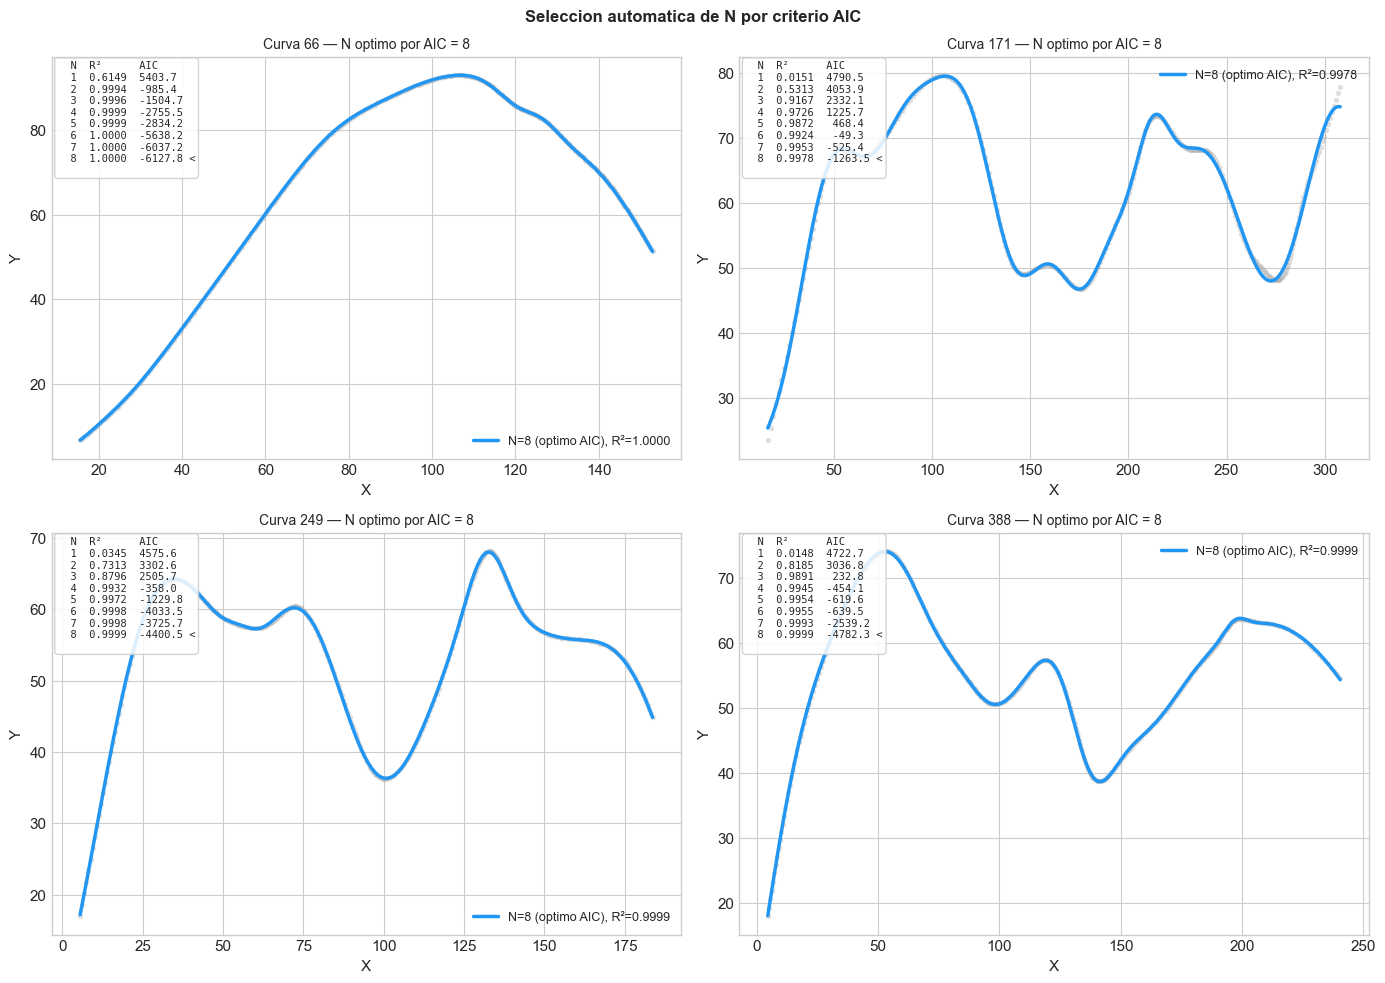

In [31]:
def calcular_aic(y_true, y_pred, n_params):
    """AIC bajo supuesto de errores gaussianos."""
    n = len(y_true)
    ssr = np.sum((y_true - y_pred)**2)
    if ssr <= 0:
        return -np.inf
    return n * np.log(ssr / n) + 2 * n_params


def seleccionar_n_optimo(xs, ys, n_max=8, delta_aic=2.0):
    """
    Prueba N = 1..n_max y selecciona el N que minimiza el AIC.
    delta_aic: tolerancia; si un N menor tiene AIC dentro de delta_aic del minimo, lo prefiere.
    Devuelve dict con todos los resultados y el N elegido.
    """
    resultados = []
    for n in range(1, n_max + 1):
        mu_locs = mu_locs_uniformes(xs, n)
        res = ajustar_suma_gaussianas(xs, ys, mu_locs)
        if res['exito']:
            k = 1 + 3 * n
            aic = calcular_aic(ys, res['y_pred'], k)
            resultados.append({'n': n, 'r2': res['r2'], 'rmse': res['rmse'],
                                'aic': aic, 'n_params': k, 'popt': res['popt']})

    if not resultados:
        return None

    df_res = pd.DataFrame(resultados)
    aic_min = df_res['aic'].min()

    # Preferir el N mas pequeño con AIC dentro de delta_aic del minimo
    candidatos = df_res[df_res['aic'] <= aic_min + delta_aic]
    n_elegido = int(candidatos.iloc[0]['n'])

    return {
        'n_optimo': n_elegido,
        'tabla': df_res,
        'mejor': df_res[df_res['n'] == n_elegido].iloc[0].to_dict(),
    }


# Demostrar seleccion en 4 curvas
curvas_sel = [66, 171, 249, 388]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, cid in enumerate(curvas_sel):
    x, y = cargar_curva(cid)
    xs, ys = x[::8], y[::8]

    resultado_sel = seleccionar_n_optimo(xs, ys, n_max=8)
    n_opt = resultado_sel['n_optimo']
    mejor = resultado_sel['mejor']
    tabla = resultado_sel['tabla']

    ax = axes[idx]

    # Curva real
    ax.scatter(xs[::3], ys[::3], s=8, alpha=0.3, color='#aaaaaa', zorder=1)

    # Ajuste con N optimo
    popt = mejor['popt']
    y_pred_opt = suma_gaussianas(xs, *popt)
    ax.plot(xs, y_pred_opt, color='#2196F3', lw=2.5, zorder=3,
            label=f"N={n_opt} (optimo AIC), R²={mejor['r2']:.4f}")

    # Para referencia, N+1
    if n_opt < 8:
        fila_sig = tabla[tabla['n'] == n_opt + 1]
        if len(fila_sig) > 0:
            popt_sig = fila_sig.iloc[0]['popt']
            y_pred_sig = suma_gaussianas(xs, *popt_sig)
            ax.plot(xs, y_pred_sig, color='#FF9800', lw=1.5, linestyle='--',
                    alpha=0.7, zorder=2,
                    label=f"N={n_opt+1}, R²={fila_sig.iloc[0]['r2']:.4f}")

    ax.set_title(f'Curva {cid} — N optimo por AIC = {n_opt}', fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(fontsize=9)

    # Insertar mini-tabla AIC
    aic_txt = '  N  R²      AIC\n'
    for _, row in tabla.iterrows():
        marker = ' <' if row['n'] == n_opt else ''
        aic_txt += f"  {int(row['n'])}  {row['r2']:.4f}  {row['aic']:6.1f}{marker}\n"
    ax.text(0.01, 0.99, aic_txt, transform=ax.transAxes,
            fontsize=7.5, va='top', ha='left', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='#cccccc'))

plt.suptitle('Seleccion automatica de N por criterio AIC', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

In [32]:
# Barrido completo de seleccion automatica en las 500 curvas
print('Ejecutando seleccion automatica de N en las 500 curvas...')

registros_auto = []
for cid in range(1, 501):
    x, y = cargar_curva(cid)
    xs, ys = x[::8], y[::8]

    n_picos = len(mu_locs_por_picos(xs, ys))
    resultado = seleccionar_n_optimo(xs, ys, n_max=8)

    if resultado:
        registros_auto.append({
            'curva': cid,
            'n_picos_detectados': n_picos,
            'n_optimo': resultado['n_optimo'],
            'r2': resultado['mejor']['r2'],
            'rmse': resultado['mejor']['rmse'],
            'aic': resultado['mejor']['aic'],
        })
    else:
        registros_auto.append({
            'curva': cid, 'n_picos_detectados': n_picos,
            'n_optimo': np.nan, 'r2': np.nan, 'rmse': np.nan, 'aic': np.nan
        })

    if cid % 100 == 0:
        print(f'  {cid}/500')

df_auto = pd.DataFrame(registros_auto)
r2_vals = df_auto['r2'].dropna()

print('\nResultados suma de gaussianas (N optimo por AIC):')
print(f'  Curvas ajustadas: {r2_vals.count()}/500')
print(f'  R² medio:         {r2_vals.mean():.4f}')
print(f'  R² mediana:       {r2_vals.median():.4f}')
print(f'  R² > 0.90:        {(r2_vals > 0.90).sum()}')
print(f'  R² > 0.95:        {(r2_vals > 0.95).sum()}')
print(f'  R² > 0.99:        {(r2_vals > 0.99).sum()}')
print(f'\nDistribucion de N optimo elegido:')
print(df_auto['n_optimo'].value_counts().sort_index().to_string()) # Tardó 43 minutos en correr

Ejecutando seleccion automatica de N en las 500 curvas...
  100/500
  200/500
  300/500
  400/500
  500/500

Resultados suma de gaussianas (N optimo por AIC):
  Curvas ajustadas: 500/500
  R² medio:         0.9997
  R² mediana:       0.9999
  R² > 0.90:        500
  R² > 0.95:        500
  R² > 0.99:        500

Distribucion de N optimo elegido:
n_optimo
5      1
6      5
7     25
8    469


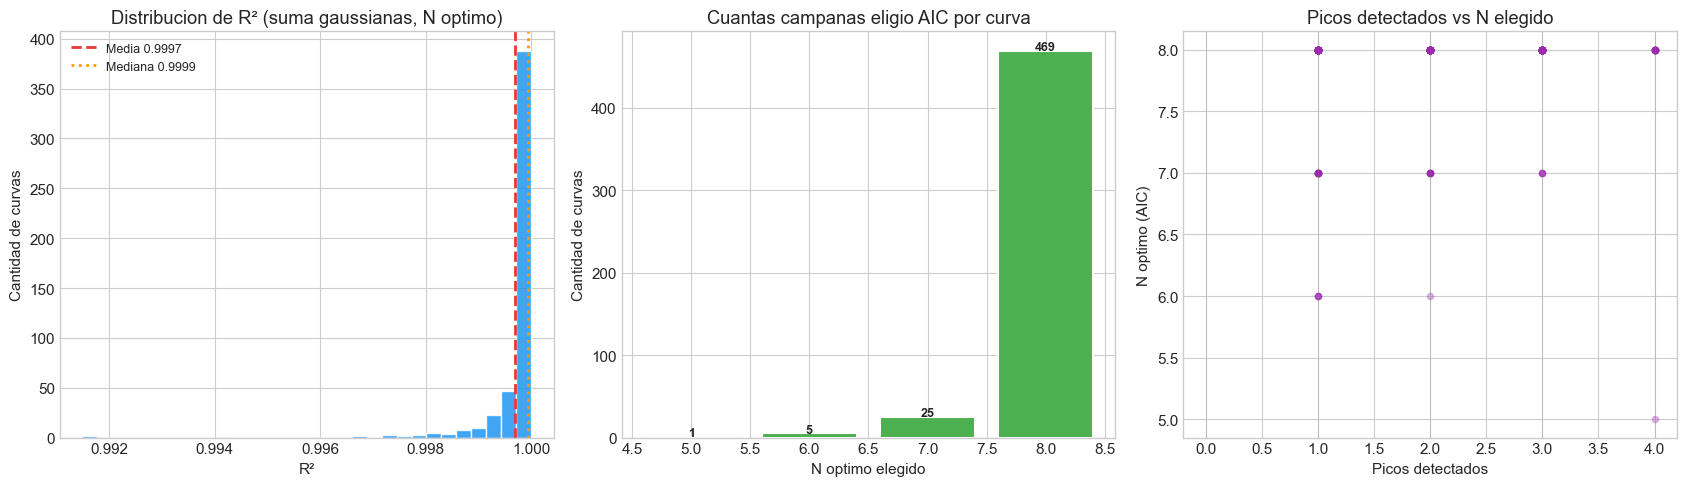

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Histograma R²
axes[0].hist(r2_vals, bins=30, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(r2_vals.mean(), color='#E53935', lw=2, linestyle='--',
                label=f'Media {r2_vals.mean():.4f}')
axes[0].axvline(r2_vals.median(), color='#FF9800', lw=2, linestyle=':',
                label=f'Mediana {r2_vals.median():.4f}')
axes[0].set_xlabel('R²')
axes[0].set_ylabel('Cantidad de curvas')
axes[0].set_title('Distribucion de R² (suma gaussianas, N optimo)')
axes[0].legend(fontsize=9)

# Distribucion de N optimo
conteos_n = df_auto['n_optimo'].dropna().value_counts().sort_index()
axes[1].bar(conteos_n.index, conteos_n.values, color='#4CAF50', edgecolor='white', lw=1.5)
for xi, vi in zip(conteos_n.index, conteos_n.values):
    axes[1].text(xi, vi + 1, str(int(vi)), ha='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('N optimo elegido')
axes[1].set_ylabel('Cantidad de curvas')
axes[1].set_title('Cuantas campanas eligio AIC por curva')

# N optimo vs n_picos detectados
axes[2].scatter(df_auto['n_picos_detectados'].values,
                df_auto['n_optimo'].values,
                alpha=0.3, s=20, color='#9C27B0')
axes[2].set_xlabel('Picos detectados')
axes[2].set_ylabel('N optimo (AIC)')
axes[2].set_title('Picos detectados vs N elegido')
for n in [0, 1, 2, 3, 4]:
    axes[2].axvline(n, color='gray', lw=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Modelo: splines

Un spline es una funcion por partes compuesta por polinomios que se empalman suavemente
en puntos llamados **nudos** (knots). A diferencia de la suma de gaussianas, que tiene
una forma funcional fija, los splines son adaptables a cualquier forma.

Trabajamos con dos variantes:

**CubicSpline** (interpolante):
- Pasa exactamente por todos los puntos de datos.
- Garantiza continuidad de la funcion, primera y segunda derivada.
- R² = 1 por construccion. El problema es que puede oscilar si los datos tienen ruido.

**UnivariateSpline** (suavizante):
- No pasa exactamente por los datos; los suaviza.
- Controla el nivel de suavizado con el parametro `s` (factor de suavizado):
  - `s` pequeño: mas nudos, mas fiel a los datos (puede sobre-ajustar ruido).
  - `s` grande: menos nudos, mas suave (puede perder detalles).
- El grado `k` del spline controla la suavidad entre nudos (tipicamente k=3 o k=5).
- El parametro `s` conveniente para datos sin ruido relevante es del orden de `0.1 * n_puntos`.

**Relacion entre nudos y parametros:**  
Un spline de grado k con m nudos usa $m + k + 1$ parametros (coeficientes de la base B-spline).
Con k=5 y m nudos: $m + 6$ parametros. Para comparar con suma de gaussianas de N campanas ($1 + 3N$
parametros), se necesitan aproximadamente $m = 3N - 5$ nudos.

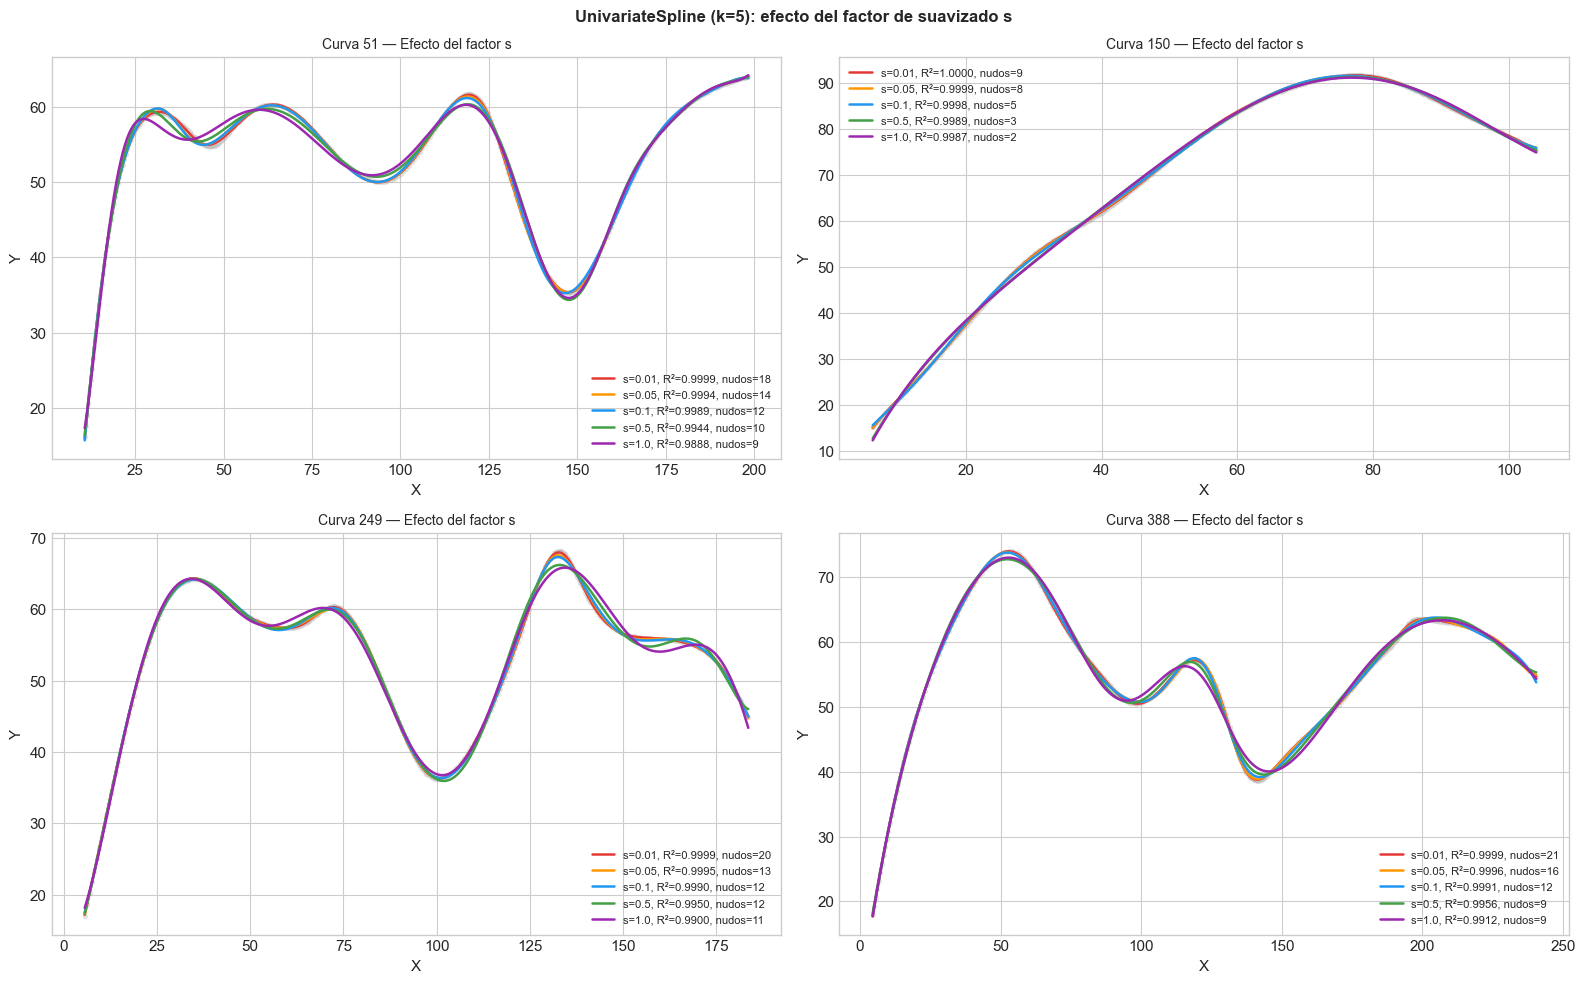

s pequeno: mas nudos, ajuste mas fiel, riesgo de sobreajuste si hay ruido.
s grande: menos nudos, curva mas suave, puede perder detalles finos.
Para datos de alta precision sin ruido, s=0.05 a s=0.1 es un buen punto de partida.


In [34]:
def ajustar_spline_suavizante(xs, ys, s_factor=0.1, k=5):
    """
    Ajusta UnivariateSpline con s = s_factor * n_puntos.
    k: grado del spline (3=cubico, 5=quintico).
    """
    try:
        spl = UnivariateSpline(xs, ys, s=s_factor * len(xs), k=k)
        y_pred = spl(xs)
        n_knots = len(spl.get_knots())
        n_params = n_knots + k + 1
        return {
            'exito': True,
            'spline': spl,
            'y_pred': y_pred,
            'r2': float(r2_score(ys, y_pred)),
            'rmse': rmse(ys, y_pred),
            'n_knots': n_knots,
            'n_params': n_params,
        }
    except Exception as e:
        return {'exito': False, 'error': str(e)}


# Demostrar efecto del factor de suavizado en 4 curvas
curvas_spl = [51, 150, 249, 388]
s_factors = [0.01, 0.05, 0.1, 0.5, 1.0]
colores_s = ['#E53935', '#FF9800', '#2196F3', '#43A047', '#9C27B0']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, cid in enumerate(curvas_spl):
    ax = axes[idx]
    x, y = cargar_curva(cid)
    xs, ys = x[::8], y[::8]

    ax.scatter(xs[::3], ys[::3], s=8, alpha=0.25, color='#aaaaaa', zorder=1)

    for s_f, col in zip(s_factors, colores_s):
        res = ajustar_spline_suavizante(xs, ys, s_factor=s_f)
        if res['exito']:
            ax.plot(xs, res['y_pred'], color=col, lw=1.8,
                    label=f"s={s_f}, R²={res['r2']:.4f}, nudos={res['n_knots']}")

    ax.set_title(f'Curva {cid} — Efecto del factor s', fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(fontsize=8)

plt.suptitle('UnivariateSpline (k=5): efecto del factor de suavizado s',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('s pequeno: mas nudos, ajuste mas fiel, riesgo de sobreajuste si hay ruido.')
print('s grande: menos nudos, curva mas suave, puede perder detalles finos.')
print('Para datos de alta precision sin ruido, s=0.05 a s=0.1 es un buen punto de partida.')

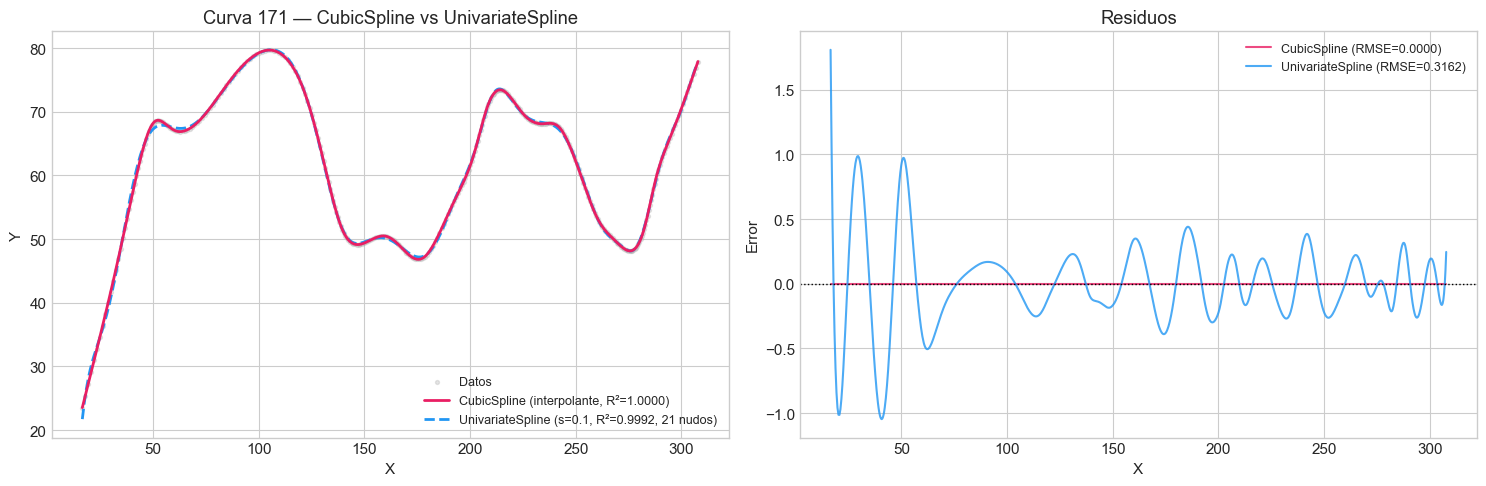

CubicSpline: R² = 1 por construccion, pasa exactamente por cada punto.
UnivariateSpline: no pasa exactamente por los datos, pero es mas estable
  y tiene menos parametros (nudos << puntos).


In [35]:
# Comparar CubicSpline (interpolante) vs UnivariateSpline (suavizante)
CID_COMP = 171
x, y = cargar_curva(CID_COMP)
xs, ys = x[::8], y[::8]

# CubicSpline: interpolante exacto
cs = CubicSpline(xs, ys)
y_cs = cs(xs)

# UnivariateSpline suavizante
res_spl = ajustar_spline_suavizante(xs, ys, s_factor=0.1, k=5)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel izquierdo: ambos modelos
axes[0].scatter(xs[::3], ys[::3], s=8, alpha=0.3, color='#aaaaaa', label='Datos', zorder=1)
axes[0].plot(xs, y_cs, color='#E91E63', lw=2, label=f'CubicSpline (interpolante, R²=1.0000)', zorder=3)
axes[0].plot(xs, res_spl['y_pred'], color='#2196F3', lw=2, linestyle='--',
             label=f"UnivariateSpline (s=0.1, R²={res_spl['r2']:.4f}, {res_spl['n_knots']} nudos)",
             zorder=2)
axes[0].set_title(f'Curva {CID_COMP} — CubicSpline vs UnivariateSpline')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].legend(fontsize=9)

# Panel derecho: residuos
res_cs = ys - y_cs
res_spl_r = ys - res_spl['y_pred']
axes[1].plot(xs, res_cs, color='#E91E63', lw=1.5, alpha=0.8, label=f'CubicSpline (RMSE={rmse(ys,y_cs):.4f})')
axes[1].plot(xs, res_spl_r, color='#2196F3', lw=1.5, alpha=0.8,
             label=f"UnivariateSpline (RMSE={res_spl['rmse']:.4f})")
axes[1].axhline(0, color='black', lw=1, linestyle=':')
axes[1].set_title('Residuos')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Error')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('CubicSpline: R² = 1 por construccion, pasa exactamente por cada punto.')
print('UnivariateSpline: no pasa exactamente por los datos, pero es mas estable')
print('  y tiene menos parametros (nudos << puntos).')

In [36]:
# Barrido completo del spline suavizante en las 500 curvas
print('Ajustando UnivariateSpline en las 500 curvas (s=0.1, k=5)...')

registros_spl = []
for cid in range(1, 501):
    x, y = cargar_curva(cid)
    xs, ys = x[::8], y[::8]
    res = ajustar_spline_suavizante(xs, ys, s_factor=0.1, k=5)
    registros_spl.append({
        'curva': cid,
        'r2_spl': res.get('r2', np.nan),
        'rmse_spl': res.get('rmse', np.nan),
        'n_knots': res.get('n_knots', np.nan),
        'n_params_spl': res.get('n_params', np.nan),
    })
    if cid % 100 == 0:
        print(f'  {cid}/500')

df_spl = pd.DataFrame(registros_spl)
r2_spl_vals = df_spl['r2_spl'].dropna()

print('\nResultados UnivariateSpline (s=0.1, k=5):')
print(f'  Curvas ajustadas: {r2_spl_vals.count()}/500')
print(f'  R² medio:         {r2_spl_vals.mean():.4f}')
print(f'  R² mediana:       {r2_spl_vals.median():.4f}')
print(f'  R² > 0.95:        {(r2_spl_vals > 0.95).sum()}')
print(f'  R² > 0.99:        {(r2_spl_vals > 0.99).sum()}')
print(f'  R² > 0.999:       {(r2_spl_vals > 0.999).sum()}')
print(f'\n  Nudos por curva: min={df_spl["n_knots"].min():.0f}, max={df_spl["n_knots"].max():.0f}, media={df_spl["n_knots"].mean():.1f}')

Ajustando UnivariateSpline en las 500 curvas (s=0.1, k=5)...
  100/500
  200/500
  300/500
  400/500
  500/500

Resultados UnivariateSpline (s=0.1, k=5):
  Curvas ajustadas: 500/500
  R² medio:         0.9994
  R² mediana:       0.9996
  R² > 0.95:        500
  R² > 0.99:        499
  R² > 0.999:       448

  Nudos por curva: min=2, max=25, media=11.0


## 8. Comparacion de metodos

Tenemos tres modelos comparables:

| Modelo | Parametros tipicos | Interpretabilidad |
|--------|-------------------|-------------------|
| 1 gaussiana (notebook 01) | 4 | Alta (A, mu, sigma, c) |
| Suma N gaussianas (N optimo) | 1 + 3N ~ 10-25 | Media (cada campana es interpretable) |
| UnivariateSpline (k=5) | n_knots + 6 ~ 8-31 | Baja (coeficientes B-spline) |

La comparacion aqui es sobre las mismas 500 curvas para que los numeros sean directamente comparables.

In [37]:
# Resultados del notebook 01 (1 sola gaussiana) recalculados aqui para comparacion limpia
from scipy.optimize import curve_fit as cf

def gaussiana_simple(x, A, mu, sigma, c):
    return A * np.exp(-((x - mu)**2) / (2 * sigma**2)) + c

def ajustar_gaussiana_simple(xs, ys):
    c0 = float(np.min(ys))
    ys_shift = ys - c0
    A0 = float(np.max(ys_shift))
    mu0 = float(xs[np.argmax(ys_shift)])
    ix = np.where(ys_shift >= A0/2)[0]
    sigma0 = float((xs[ix[-1]] - xs[ix[0]]) / 2.355) if len(ix) >= 2 else (xs.max() - xs.min()) / 6
    try:
        popt, _ = cf(gaussiana_simple, xs, ys, p0=[A0, mu0, max(sigma0, 1e-6), c0], maxfev=50000)
        y_pred = gaussiana_simple(xs, *popt)
        return {'exito': True, 'r2': float(r2_score(ys, y_pred)), 'n_params': 4}
    except:
        return {'exito': False, 'r2': np.nan, 'n_params': 4}

print('Recalculando gaussiana simple en 500 curvas...')
registros_g1 = []
for cid in range(1, 501):
    x, y = cargar_curva(cid)
    xs, ys = x[::8], y[::8]
    res = ajustar_gaussiana_simple(xs, ys)
    registros_g1.append({'curva': cid, 'r2_g1': res['r2']})
    if cid % 100 == 0:
        print(f'  {cid}/500')

df_g1 = pd.DataFrame(registros_g1)

# Combinar todos los resultados
df_comp = df_g1.copy()
df_comp = df_comp.merge(df_auto[['curva', 'r2', 'n_optimo']], on='curva', how='left')
df_comp = df_comp.rename(columns={'r2': 'r2_ng', 'n_optimo': 'n_campanas'})
df_comp = df_comp.merge(df_spl[['curva', 'r2_spl', 'n_knots']], on='curva', how='left')

print('\nResumen comparativo:')
for col, nombre in [('r2_g1', '1 Gaussiana'), ('r2_ng', 'Suma N Gaussianas'), ('r2_spl', 'Spline (s=0.1)')]:
    vals = df_comp[col].dropna()
    print(f'\n  {nombre}:')
    print(f'    R² medio:   {vals.mean():.4f}')
    print(f'    R² mediana: {vals.median():.4f}')
    print(f'    R² > 0.90:  {(vals > 0.90).sum()}/500')
    print(f'    R² > 0.95:  {(vals > 0.95).sum()}/500')
    print(f'    R² > 0.99:  {(vals > 0.99).sum()}/500')

Recalculando gaussiana simple en 500 curvas...
  100/500
  200/500
  300/500
  400/500
  500/500

Resumen comparativo:

  1 Gaussiana:
    R² medio:   0.7432
    R² mediana: 0.8150
    R² > 0.90:  174/500
    R² > 0.95:  112/500
    R² > 0.99:  36/500

  Suma N Gaussianas:
    R² medio:   0.9997
    R² mediana: 0.9999
    R² > 0.90:  500/500
    R² > 0.95:  500/500
    R² > 0.99:  500/500

  Spline (s=0.1):
    R² medio:   0.9994
    R² mediana: 0.9996
    R² > 0.90:  500/500
    R² > 0.95:  500/500
    R² > 0.99:  499/500


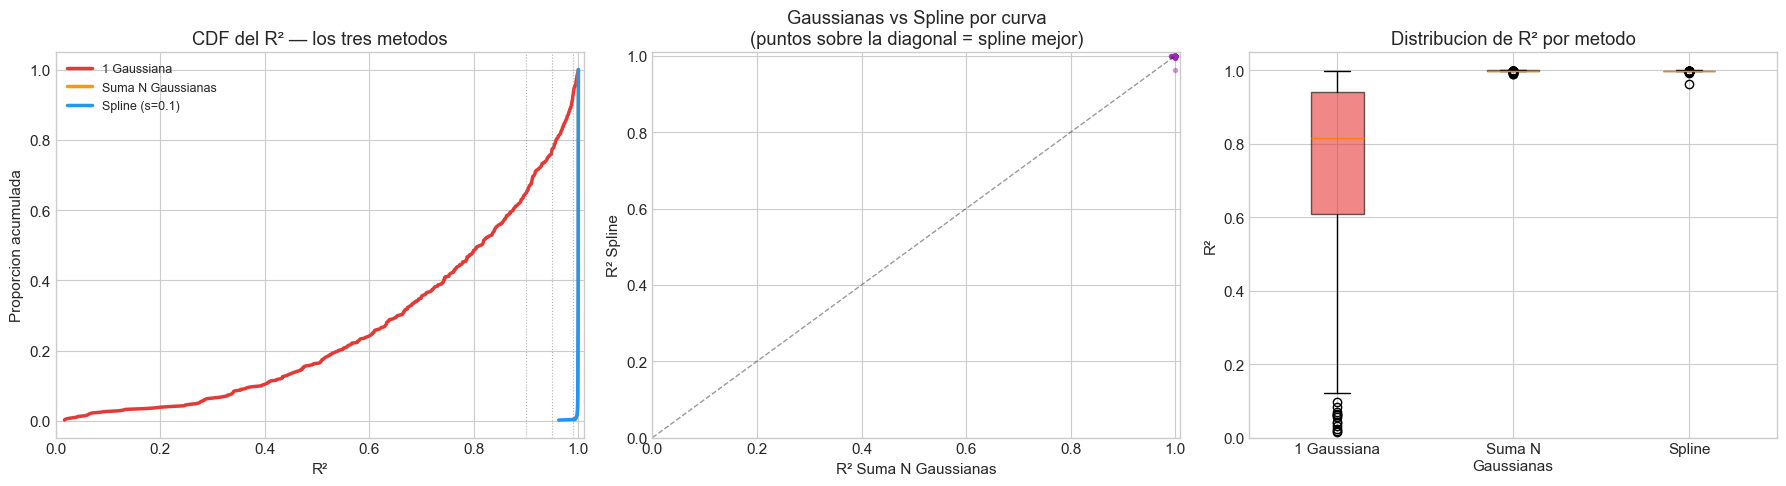

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CDF comparativa
ax = axes[0]
for col, nombre, col_color in [
    ('r2_g1', '1 Gaussiana', '#E53935'),
    ('r2_ng', f'Suma N Gaussianas', '#FF9800'),
    ('r2_spl', 'Spline (s=0.1)', '#2196F3'),
]:
    vals = np.sort(df_comp[col].dropna().values)
    cdf = np.arange(1, len(vals)+1) / len(vals)
    ax.plot(vals, cdf, color=col_color, lw=2.5, label=nombre)

for thresh in [0.90, 0.95, 0.99]:
    ax.axvline(thresh, color='gray', lw=0.8, linestyle=':', alpha=0.6)
ax.set_xlabel('R²')
ax.set_ylabel('Proporcion acumulada')
ax.set_title('CDF del R² — los tres metodos')
ax.legend(fontsize=9)
ax.set_xlim(0, 1.01)

# Scatter: gaussiana N vs spline
ax = axes[1]
ax.scatter(df_comp['r2_ng'], df_comp['r2_spl'], s=8, alpha=0.4, color='#9C27B0')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
ax.set_xlabel('R² Suma N Gaussianas')
ax.set_ylabel('R² Spline')
ax.set_title('Gaussianas vs Spline por curva\n(puntos sobre la diagonal = spline mejor)')
ax.set_xlim(0, 1.01)
ax.set_ylim(0, 1.01)

# Boxplot
ax = axes[2]
datos_box = [
    df_comp['r2_g1'].dropna().values,
    df_comp['r2_ng'].dropna().values,
    df_comp['r2_spl'].dropna().values,
]
bp = ax.boxplot(datos_box, labels=['1 Gaussiana', 'Suma N\nGaussianas', 'Spline'],
                patch_artist=True, notch=False)
colores_bp = ['#E53935', '#FF9800', '#2196F3']
for patch, col in zip(bp['boxes'], colores_bp):
    patch.set_facecolor(col)
    patch.set_alpha(0.6)
ax.set_ylabel('R²')
ax.set_title('Distribucion de R² por metodo')
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

In [39]:
# Ver cuántas curvas mejoran significativamente con la suma de gaussianas vs 1 sola
mejora_sg_vs_g1 = df_comp['r2_ng'] - df_comp['r2_g1']
mejora_spl_vs_g1 = df_comp['r2_spl'] - df_comp['r2_g1']

print('Mejora en R² respecto a 1 gaussiana (notebook 01):')
print(f'  Suma N Gaussianas vs 1G:')
print(f'    Mejora media:   {mejora_sg_vs_g1.mean():.4f}')
print(f'    Mejora > 0.10:  {(mejora_sg_vs_g1 > 0.10).sum()} curvas')
print(f'    Mejora > 0.05:  {(mejora_sg_vs_g1 > 0.05).sum()} curvas')
print(f'    Sin mejora (<0): {(mejora_sg_vs_g1 < 0).sum()} curvas')
print(f'  Spline vs 1G:')
print(f'    Mejora media:   {mejora_spl_vs_g1.mean():.4f}')
print(f'    Mejora > 0.10:  {(mejora_spl_vs_g1 > 0.10).sum()} curvas')
print(f'    Sin mejora (<0): {(mejora_spl_vs_g1 < 0).sum()} curvas')

# Curvas donde la suma de gaussianas sigue siendo mala
malas_sg = df_comp[df_comp['r2_ng'] < 0.90].sort_values('r2_ng')
print(f'\nCurvas con R² < 0.90 en suma de gaussianas: {len(malas_sg)}')
if len(malas_sg) > 0:
    print(malas_sg[['curva', 'r2_g1', 'r2_ng', 'r2_spl', 'n_campanas']].head(15).to_string(index=False))

Mejora en R² respecto a 1 gaussiana (notebook 01):
  Suma N Gaussianas vs 1G:
    Mejora media:   0.2565
    Mejora > 0.10:  319 curvas
    Mejora > 0.05:  381 curvas
    Sin mejora (<0): 0 curvas
  Spline vs 1G:
    Mejora media:   0.2562
    Mejora > 0.10:  319 curvas
    Sin mejora (<0): 0 curvas

Curvas con R² < 0.90 en suma de gaussianas: 0


## 9. Casos dificiles

Inspeccionamos las curvas donde la suma de gaussianas sigue teniendo dificultades,
para entender por que y comparar visualmente con el spline.

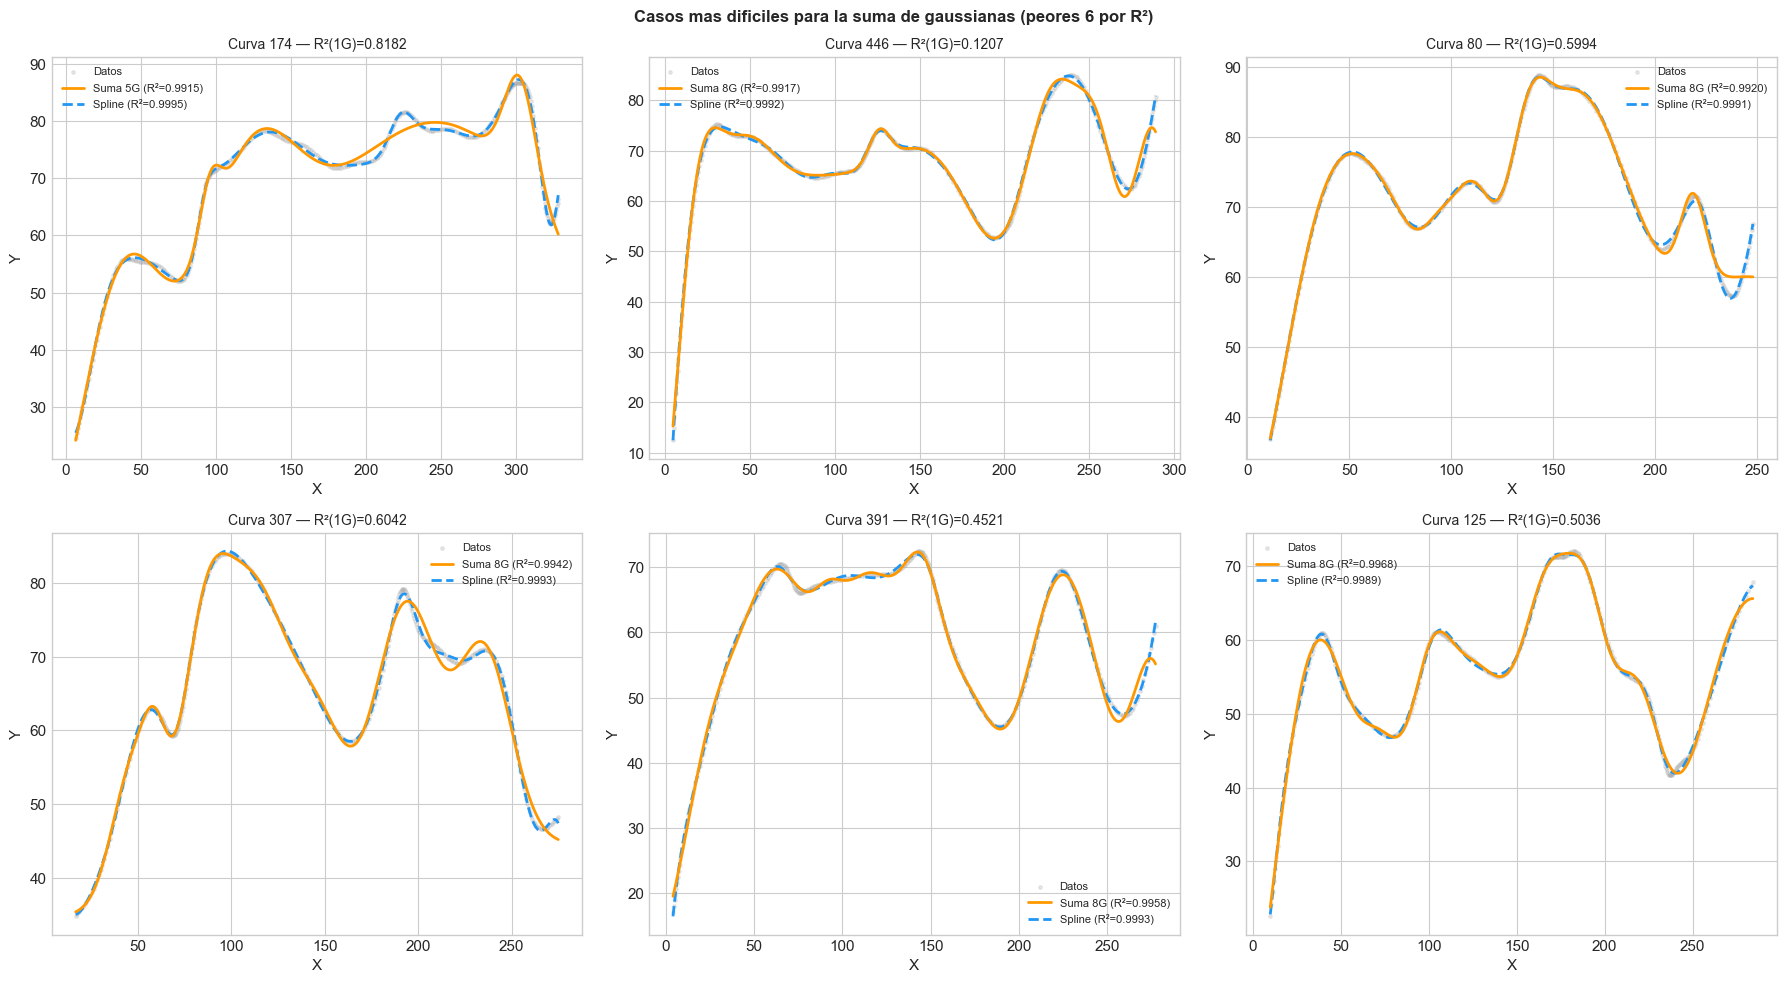

En estos casos el spline supera ampliamente a la suma de gaussianas.
Estos son tipicamente curvas con:
  - Una linea base no plana (creciente, decreciente o con curvatura)
  - Picos asimetricos o con pendientes muy distintas a cada lado
  - Formas que no se descomponen naturalmente en campanas simetricas


In [40]:
# Visualizar los 6 peores casos de la suma de gaussianas
peores = df_comp.nsmallest(6, 'r2_ng')['curva'].values

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, cid in enumerate(peores):
    ax = axes[idx]
    x, y = cargar_curva(cid)
    xs, ys = x[::8], y[::8]

    ax.scatter(xs[::3], ys[::3], s=6, alpha=0.25, color='#aaaaaa', zorder=1, label='Datos')

    # Suma de gaussianas con N optimo
    n_opt = int(df_comp[df_comp['curva'] == cid]['n_campanas'].values[0])
    mu_locs = mu_locs_uniformes(xs, n_opt)
    res_sg = ajustar_suma_gaussianas(xs, ys, mu_locs)
    if res_sg['exito']:
        ax.plot(xs, res_sg['y_pred'], color='#FF9800', lw=2,
                label=f"Suma {n_opt}G (R²={res_sg['r2']:.4f})", zorder=3)

    # Spline
    res_spl = ajustar_spline_suavizante(xs, ys, s_factor=0.1)
    if res_spl['exito']:
        ax.plot(xs, res_spl['y_pred'], color='#2196F3', lw=2, linestyle='--',
                label=f"Spline (R²={res_spl['r2']:.4f})", zorder=2)

    r2_g1_val = float(df_comp[df_comp['curva'] == cid]['r2_g1'].values[0])
    ax.set_title(f'Curva {cid} — R²(1G)={r2_g1_val:.4f}', fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(fontsize=8)

plt.suptitle('Casos mas dificiles para la suma de gaussianas (peores 6 por R²)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('En estos casos el spline supera ampliamente a la suma de gaussianas.')
print('Estos son tipicamente curvas con:')
print('  - Una linea base no plana (creciente, decreciente o con curvatura)')
print('  - Picos asimetricos o con pendientes muy distintas a cada lado')
print('  - Formas que no se descomponen naturalmente en campanas simetricas')

In [41]:
# Analizar la forma de los peores casos
print('Analisis de las curvas dificiles para la suma de gaussianas:\n')
for cid in peores:
    x, y = cargar_curva(cid)
    xs, ys = x[::8], y[::8]
    peaks, valleys, _, _ = contar_picos(xs, ys)

    dy = np.gradient(ys, xs)
    d2y = np.gradient(dy, xs)
    cambios_concavidad = np.sum(np.diff(np.sign(d2y)) != 0)

    y_inicio, y_fin = ys[0], ys[-1]
    tendencia = y_fin - y_inicio

    r2_ng_val = df_comp[df_comp['curva'] == cid]['r2_ng'].values[0]
    r2_spl_val = df_comp[df_comp['curva'] == cid]['r2_spl'].values[0]

    print(f'Curva {cid}:')
    print(f'  R² suma_G={r2_ng_val:.4f},  R² spline={r2_spl_val:.4f}')
    print(f'  Picos: {len(peaks)},  valles: {len(valleys)}')
    print(f'  Cambios de concavidad: {cambios_concavidad}')
    print(f'  Tendencia Y (fin-inicio): {tendencia:.2f} ({"creciente" if tendencia > 0 else "decreciente"})')
    print()

Analisis de las curvas dificiles para la suma de gaussianas:

Curva 174:
  R² suma_G=0.9915,  R² spline=0.9995
  Picos: 4,  valles: 4
  Cambios de concavidad: 18
  Tendencia Y (fin-inicio): 41.70 (creciente)

Curva 446:
  R² suma_G=0.9917,  R² spline=0.9992
  Picos: 3,  valles: 3
  Cambios de concavidad: 11
  Tendencia Y (fin-inicio): 68.16 (creciente)

Curva 80:
  R² suma_G=0.9920,  R² spline=0.9991
  Picos: 4,  valles: 4
  Cambios de concavidad: 10
  Tendencia Y (fin-inicio): 30.74 (creciente)

Curva 307:
  R² suma_G=0.9942,  R² spline=0.9993
  Picos: 3,  valles: 2
  Cambios de concavidad: 12
  Tendencia Y (fin-inicio): 13.47 (creciente)

Curva 391:
  R² suma_G=0.9958,  R² spline=0.9993
  Picos: 3,  valles: 3
  Cambios de concavidad: 11
  Tendencia Y (fin-inicio): 43.93 (creciente)

Curva 125:
  R² suma_G=0.9968,  R² spline=0.9989
  Picos: 3,  valles: 3
  Cambios de concavidad: 14
  Tendencia Y (fin-inicio): 45.39 (creciente)



## 10. Conclusiones — Comparacion de los tres metodos

> **Nota:** Ejecuta primero la celda de *Setup* (arriba) y luego todas las celdas de esta seccion en orden. No se necesita correr nada anterior.

In [81]:
# ============================================================
# SETUP — sección 10 en adelante es autónoma desde aquí
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json as _json
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.interpolate import UnivariateSpline
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 100})

TARGET_DIR = Path('../..') / 'datos' / 'target'

def cargar_curva(curve_id):
    path = TARGET_DIR / f'curve_{curve_id:04d}.txt'
    data = np.loadtxt(path, delimiter=',')
    return data[:, 0], data[:, 1]

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# --- Modelo: suma de gaussianas ---
def suma_gaussianas(x, *params):
    c = params[0]
    result = np.full_like(x, c, dtype=float)
    n = (len(params) - 1) // 3
    for i in range(n):
        A, mu, sig = params[1+3*i], params[2+3*i], params[3+3*i]
        result += A * np.exp(-((x - mu)**2) / (2 * sig**2))
    return result

def construir_p0_bounds(xs, ys, mu_locs):
    n = len(mu_locs)
    rango_x = float(xs.max() - xs.min())
    rango_y = float(ys.max() - ys.min())
    c0 = float(ys.min())
    p0  = [c0];  blo = [c0 - rango_y - 1];  bhi = [float(ys.max())]
    for mu0 in mu_locs:
        idx_near = int(np.argmin(np.abs(xs - mu0)))
        A0 = max(float(ys[idx_near] - c0), 0.1)
        s0 = rango_x / (3.0 * n)
        p0  += [A0, float(mu0), s0]
        blo += [0.0, float(xs.min()), 0.5]
        bhi += [A0 * 5 + 1, float(xs.max()), rango_x]
    return p0, blo, bhi

def ajustar_suma_gaussianas(xs, ys, mu_locs, maxfev=80000):
    p0, blo, bhi = construir_p0_bounds(xs, ys, mu_locs)
    try:
        popt, _ = curve_fit(suma_gaussianas, xs, ys,
                            p0=p0, bounds=(blo, bhi), maxfev=maxfev, method='trf')
        y_pred = suma_gaussianas(xs, *popt)
        return {'exito': True, 'popt': popt, 'y_pred': y_pred,
                'r2': float(r2_score(ys, y_pred)), 'rmse': rmse(ys, y_pred),
                'n_campanas': len(mu_locs)}
    except Exception as e:
        return {'exito': False, 'error': str(e), 'n_campanas': len(mu_locs)}

def mu_locs_uniformes(xs, n):
    margin = (xs.max() - xs.min()) * 0.05
    return np.linspace(xs.min() + margin, xs.max() - margin, n)

# --- Modelo: spline suavizante ---
def ajustar_spline_suavizante(xs, ys, s_factor=0.1, k=5):
    try:
        spl = UnivariateSpline(xs, ys, s=s_factor * len(xs), k=k)
        y_pred = spl(xs)
        n_knots = len(spl.get_knots())
        return {'exito': True, 'spline': spl, 'y_pred': y_pred,
                'r2': float(r2_score(ys, y_pred)), 'rmse': rmse(ys, y_pred),
                'n_knots': n_knots, 'n_params': n_knots + k + 1}
    except Exception as e:
        return {'exito': False, 'error': str(e)}

METODOS = [
    ('Polinomio (grado optimo)',  'poly_r2',   'poly_rmse',   'poly_n_params',  '#E53935', 'polinomio'),
    ('Suma N Gaussianas (AIC)',   'gauss_r2',  'gauss_rmse',  'gauss_n_params', '#FF9800', 'gaussianas'),
    ('UnivariateSpline (s=0.1)', 'spline_r2', 'spline_rmse', 'spline_n_params', '#2196F3', 'spline'),
]

print('Setup completo. Listo para ejecutar seccion 10 en adelante.')


Setup completo. Listo para ejecutar seccion 10 en adelante.


In [82]:
# Cargar el CSV comparativo de los tres metodos
CSV_COMP = Path('../comparacion/comparacion_3_metodos.csv')
df3 = pd.read_csv(CSV_COMP)

# Tabla resumen

resumen = []
for nombre, col_r2, col_rmse, col_np, _, key in METODOS:
    v = df3[col_r2].dropna()
    resumen.append({
        'Metodo':       nombre,
        'R2_medio':     round(v.mean(), 4),
        'R2_mediana':   round(v.median(), 4),
        'RMSE_medio':   round(df3[col_rmse].mean(), 4),
        'R2>0.99':      int((v > 0.99).sum()),
        'R2>0.999':     int((v > 0.999).sum()),
        'Params_medio': round(df3[col_np].mean(), 1),
        'Gana_en':      int((df3['mejor_metodo'] == key).sum()),
    })

df_resumen3 = pd.DataFrame(resumen).set_index('Metodo')
print('Resumen comparativo — 3 metodos en 500 curvas:')
display(df_resumen3)

print(f'\nCurvas donde cada metodo es el mejor:')
print(df3['mejor_metodo'].value_counts().to_string())


Resumen comparativo — 3 metodos en 500 curvas:


,R2_medio,R2_mediana,RMSE_medio,R2>0.99,R2>0.999,Params_medio,Gana_en
Metodo,,,,,,,
Polinomio (grado optimo),0.9981,0.9996,0.4330,478,317,20.3,109
Suma N Gaussianas (AIC),0.9997,0.9999,0.1616,500,464,24.8,314
UnivariateSpline (s=0.1),0.9994,0.9996,0.3081,499,448,16.0,77



Curvas donde cada metodo es el mejor:
mejor_metodo
gaussianas    314
polinomio     109
spline         77


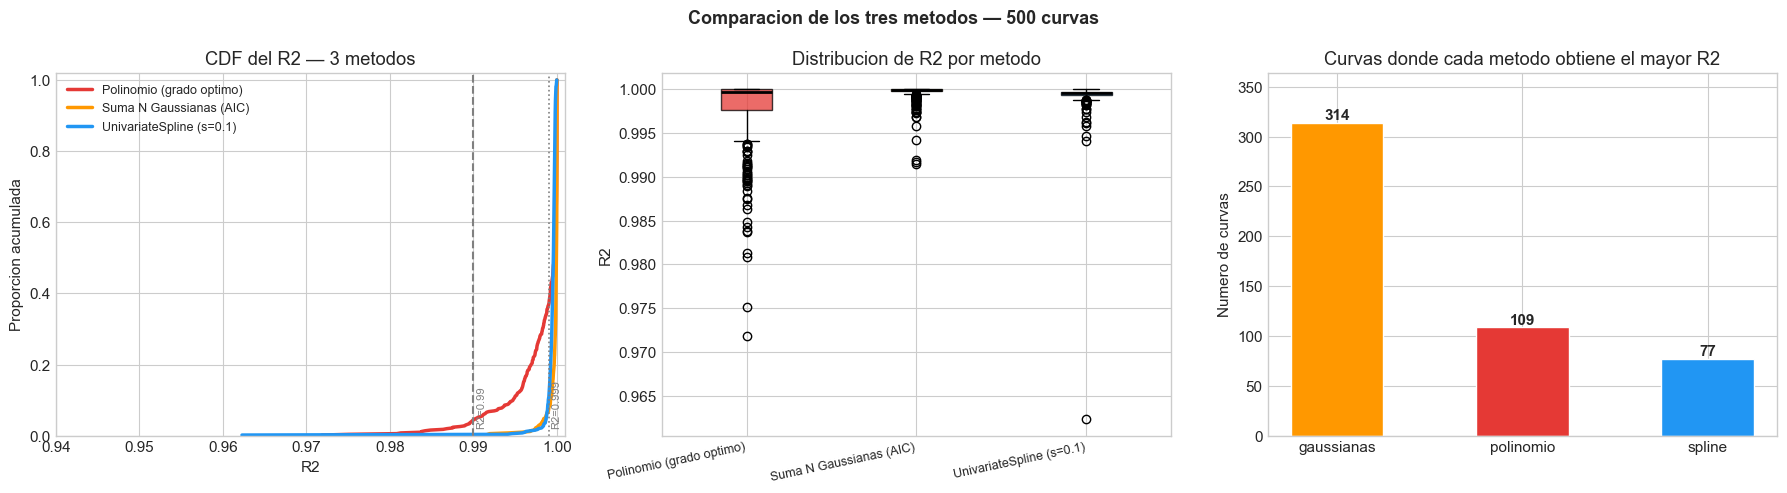

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- CDF de R² ---
ax = axes[0]
for nombre, col_r2, _, _, color, _ in METODOS:
    vals = np.sort(df3[col_r2].dropna().values)
    cdf  = np.arange(1, len(vals)+1) / len(vals)
    ax.plot(vals, cdf, color=color, lw=2.5, label=nombre)
ax.axvline(0.99,  color='gray', linestyle='--', lw=1.5)
ax.axvline(0.999, color='gray', linestyle=':',  lw=1.2)
ax.text(0.9903, 0.02, 'R2=0.99',  fontsize=8, color='gray', rotation=90, va='bottom')
ax.text(0.9993, 0.02, 'R2=0.999', fontsize=8, color='gray', rotation=90, va='bottom')
ax.set_xlabel('R2'); ax.set_ylabel('Proporcion acumulada')
ax.set_title('CDF del R2 — 3 metodos')
ax.legend(fontsize=9); ax.set_xlim(0.94, 1.001); ax.set_ylim(0, 1.02)

# --- Boxplot de R² ---
ax = axes[1]
data_box   = [df3[col].dropna().values for _, col, _, _, _, _ in METODOS]
nombres_bp = [n for n,_,_,_,_,_ in METODOS]
bp = ax.boxplot(data_box, labels=nombres_bp, patch_artist=True,
                medianprops=dict(color='black', lw=2))
for patch, (_, _, _, _, color, _) in zip(bp['boxes'], METODOS):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_ylabel('R2'); ax.set_title('Distribucion de R2 por metodo')
ax.set_xticklabels(nombres_bp, rotation=12, ha='right', fontsize=9)

# --- Barras: cuantas curvas gana cada metodo ---
ax = axes[2]
vc = df3['mejor_metodo'].value_counts()
color_map = {'polinomio': '#E53935', 'gaussianas': '#FF9800', 'spline': '#2196F3'}
bars = ax.bar(vc.index, vc.values,
              color=[color_map.get(k, 'gray') for k in vc.index],
              edgecolor='white', width=0.5)
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, v+3, str(v),
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Numero de curvas'); ax.set_ylim(0, vc.max()+50)
ax.set_title('Curvas donde cada metodo obtiene el mayor R2')

plt.suptitle('Comparacion de los tres metodos — 500 curvas', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


Curvas con mayor diferencia de R2 entre metodos:


,curva,mejor_metodo,poly_r2,gauss_r2,spline_r2,r2_diff
0,360,polinomio,0.999934,0.999912,0.962293,0.037641
1,87,gaussianas,0.971848,0.999872,0.999149,0.028024
2,454,spline,0.975070,0.999228,0.999479,0.024409
3,236,gaussianas,0.981297,0.999719,0.998974,0.018422
4,132,spline,0.980828,0.998359,0.998726,0.017898
5,355,gaussianas,0.983798,0.999627,0.999479,0.015829


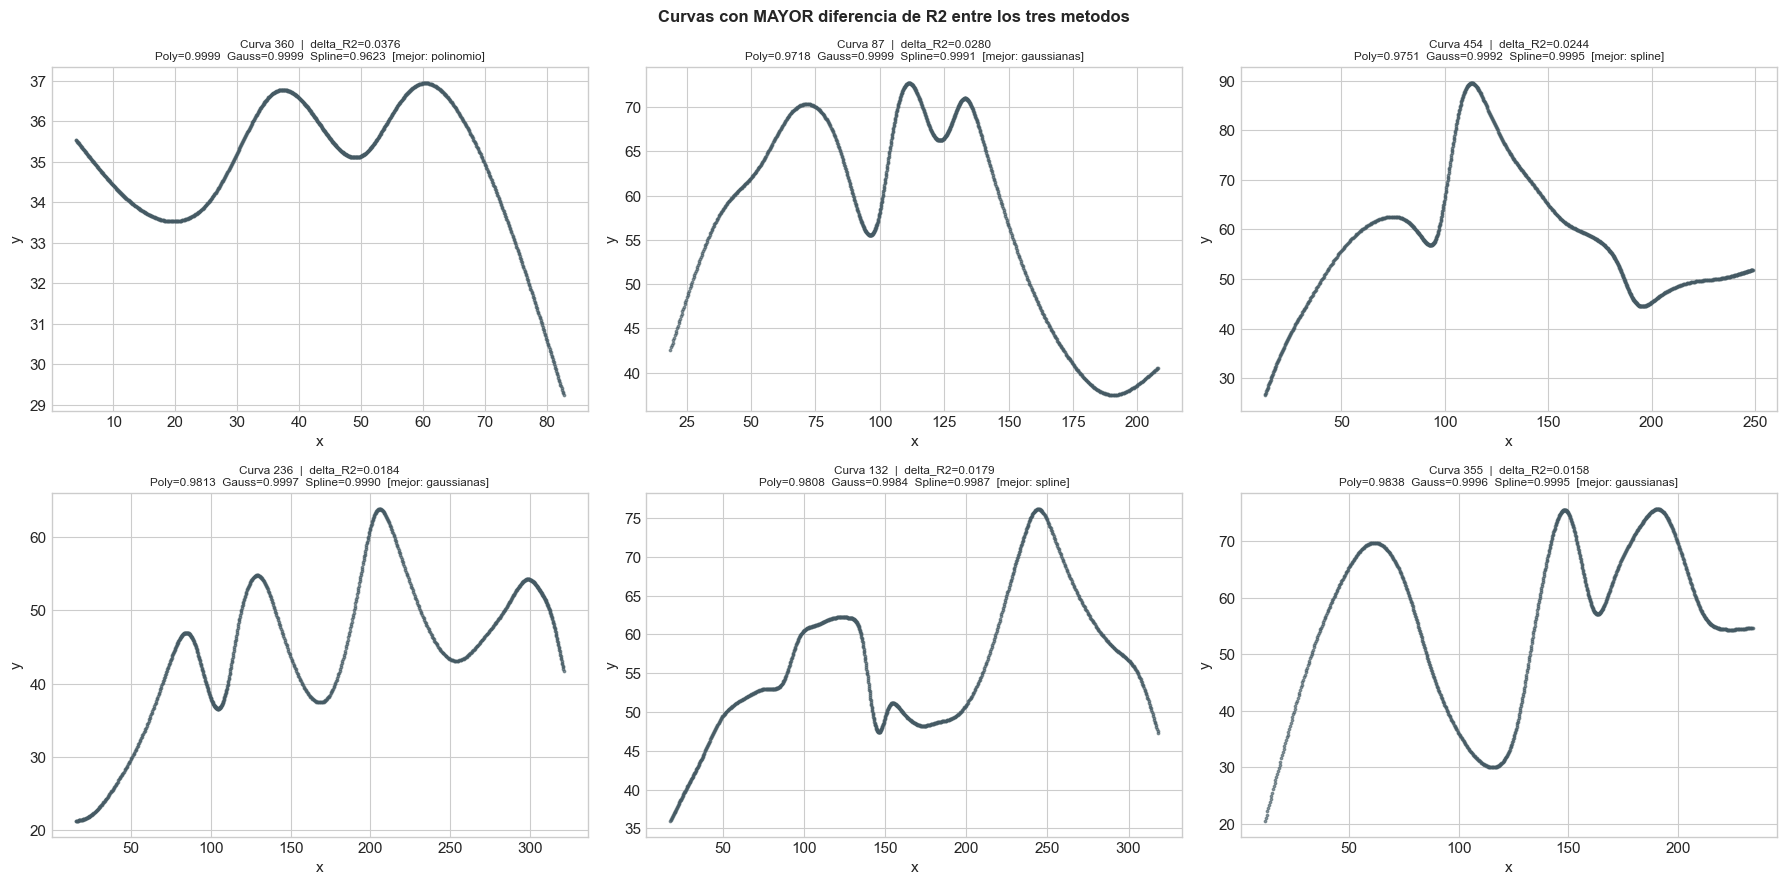

In [84]:
# Curvas donde los tres metodos difieren MAS entre si
df3['r2_diff'] = (df3[['poly_r2','gauss_r2','spline_r2']].max(axis=1)
               - df3[['poly_r2','gauss_r2','spline_r2']].min(axis=1))

top_diff = df3.nlargest(6, 'r2_diff').reset_index(drop=True)

print('Curvas con mayor diferencia de R2 entre metodos:')
display(top_diff[['curva','mejor_metodo','poly_r2','gauss_r2','spline_r2','r2_diff']])

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, (_, row) in zip(axes.flat, top_diff.iterrows()):
    cid = int(row['curva'])
    x, y = cargar_curva(cid)
    xs, ys = x[::8], y[::8]
    ax.scatter(xs, ys, s=3, color='#455A64', alpha=0.6)
    titulo = (f'Curva {cid}  |  delta_R2={row["r2_diff"]:.4f}\n'
              f'Poly={row["poly_r2"]:.4f}  '
              f'Gauss={row["gauss_r2"]:.4f}  '
              f'Spline={row["spline_r2"]:.4f}  '
              f'[mejor: {row["mejor_metodo"]}]')
    ax.set_title(titulo, fontsize=8.5)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('Curvas con MAYOR diferencia de R2 entre los tres metodos',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


Curvas con menor diferencia de R2 entre metodos (todos igualmente buenos):


,curva,mejor_metodo,poly_r2,gauss_r2,spline_r2,r2_diff
0,201,polinomio,1.000000,1.000000,0.999984,0.000016
1,227,polinomio,1.000000,1.000000,0.999984,0.000016
2,413,polinomio,1.000000,1.000000,0.999968,0.000032
3,140,polinomio,1.000000,0.999979,0.999962,0.000038
4,336,polinomio,1.000000,0.999999,0.999959,0.000041
5,290,gaussianas,0.999642,0.999643,0.999593,0.000050


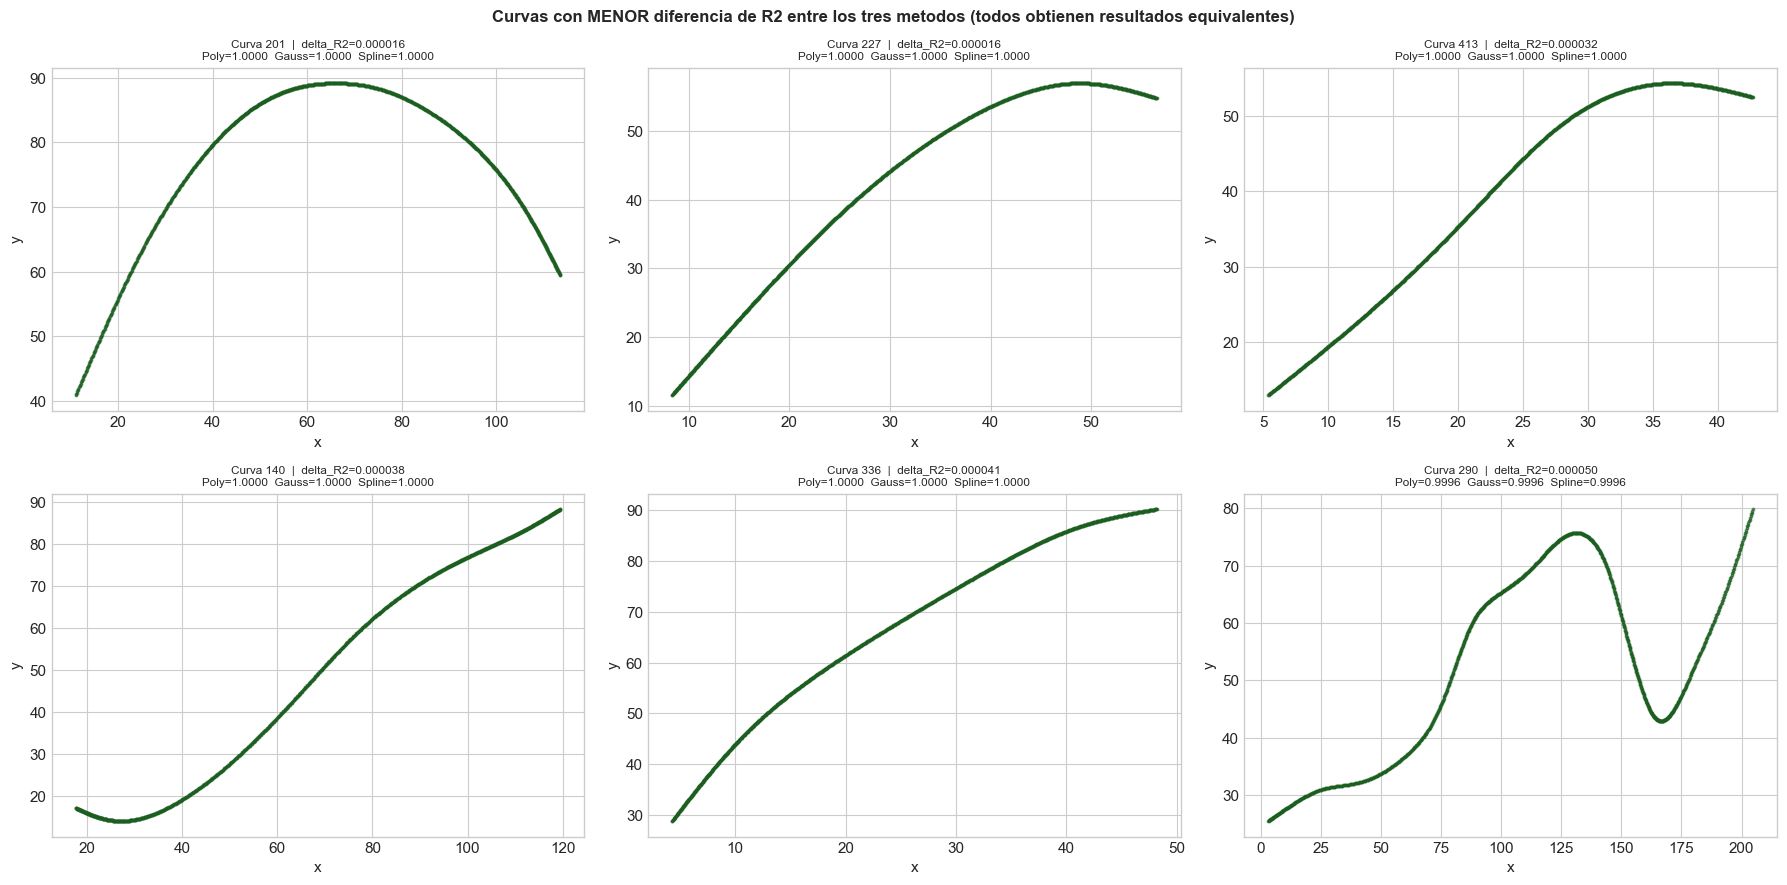

In [85]:
# Curvas donde los tres metodos son casi equivalentes
bot_diff = df3.nsmallest(6, 'r2_diff').reset_index(drop=True)

print('Curvas con menor diferencia de R2 entre metodos (todos igualmente buenos):')
display(bot_diff[['curva','mejor_metodo','poly_r2','gauss_r2','spline_r2','r2_diff']])

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, (_, row) in zip(axes.flat, bot_diff.iterrows()):
    cid = int(row['curva'])
    x, y = cargar_curva(cid)
    xs, ys = x[::8], y[::8]
    ax.scatter(xs, ys, s=3, color='#1B5E20', alpha=0.6)
    titulo = (f'Curva {cid}  |  delta_R2={row["r2_diff"]:.6f}\n'
              f'Poly={row["poly_r2"]:.4f}  '
              f'Gauss={row["gauss_r2"]:.4f}  '
              f'Spline={row["spline_r2"]:.4f}')
    ax.set_title(titulo, fontsize=8.5)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle(
    'Curvas con MENOR diferencia de R2 entre los tres metodos'
    ' (todos obtienen resultados equivalentes)',
    fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


## 11. Tabla de mejores parametros por curva

Esta seccion extrae y consolida, para cada una de las 500 curvas, los parametros numericos
del ajuste de cada metodo. El resultado se guarda en tres archivos:

- `parametros_por_curva_resumen.csv`: una fila por curva con las metricas y el mejor metodo.
- `parametros_gaussianas_por_curva.csv`: parametros c, A_i, mu_i, sigma_i expandidos.
- `parametros_spline_por_curva.json`: posiciones de nudos y coeficientes B-spline.

La tabla permite reproducir cualquier ajuste directamente sin re-ejecutar la optimizacion.

Columnas clave de la tabla resumen:

| Columna | Significado |
|---------|-------------|
| `curva` | Identificador de la curva (1 a 500) |
| `mejor_metodo` | `gauss_N` o `spline` segun mayor R² |
| `r2_mejor` | R² del metodo ganador |
| `r2_gauss` | R² de la suma de gaussianas (N optimo) |
| `r2_spline` | R² del spline suavizante (s=0.1, k=5) |
| `n_campanas` | N optimo de campanas elegido por AIC |
| `c` | Linea base de la suma de gaussianas |
| `A_i`, `mu_i`, `sigma_i` | Parametros de la campana i |
| `n_knots` | Numero de nudos del spline |

In [87]:
# Extraer parametros completos de ambos metodos para las 500 curvas
# Usa df3 (cargado del CSV) — no requiere los barridos lentos
import json as _json

print('Extrayendo parametros de los dos metodos para las 500 curvas...')

df3_idx = df3.set_index('curva')
registros_params = []

for cid in range(1, 501):
    x, y = cargar_curva(cid)
    xs, ys = x[::8], y[::8]

    row_csv = df3_idx.loc[cid]

    # N optimo y R2 desde el CSV (ya calculados en el barrido previo)
    n_opt = int(row_csv['gauss_n_campanas']) if not (isinstance(row_csv['gauss_n_campanas'], float) and (row_csv['gauss_n_campanas'] != row_csv['gauss_n_campanas'])) else 3
    r2_ng  = float(row_csv['gauss_r2'])
    r2_spl = float(row_csv['spline_r2'])

    row = {'curva': cid, 'n_campanas': n_opt, 'r2_gauss': round(r2_ng, 6)}

    # Re-ajustar gaussianas con N conocido para obtener parametros individuales
    mu_locs = mu_locs_uniformes(xs, n_opt)
    res_sg  = ajustar_suma_gaussianas(xs, ys, mu_locs)
    if res_sg['exito']:
        popt = res_sg['popt']
        row['c'] = round(float(popt[0]), 6)
        for i in range(n_opt):
            row[f'A_{i+1}']     = round(float(popt[1 + 3*i]), 6)
            row[f'mu_{i+1}']    = round(float(popt[2 + 3*i]), 6)
            row[f'sigma_{i+1}'] = round(float(popt[3 + 3*i]), 6)
    else:
        row['c'] = np.nan

    # Re-ajustar spline para obtener nudos y coeficientes
    row['r2_spline'] = round(r2_spl, 6)
    res_spl = ajustar_spline_suavizante(xs, ys, s_factor=0.1, k=5)
    if res_spl['exito']:
        spl_obj = res_spl['spline']
        knots = spl_obj.get_knots()
        coefs = spl_obj.get_coeffs()
        row['n_knots'] = len(knots)
        row['knots']   = [round(float(k), 4) for k in knots]
        row['coef']    = [round(float(c), 6) for c in coefs]
    else:
        row['n_knots'] = np.nan
        row['knots']   = []
        row['coef']    = []

    # Mejor metodo y r2_mejor directamente del CSV
    row['mejor_metodo'] = row_csv['mejor_metodo']
    row['r2_mejor']     = round(float(row_csv['r2_mejor']), 6)

    registros_params.append(row)

    if cid % 100 == 0:
        print(f'  {cid}/500')

df_params = pd.DataFrame(registros_params)
print(f'Tabla generada: {len(df_params)} filas, {len(df_params.columns)} columnas.')
print(f'Mejor metodo por curva:')
print(df_params['mejor_metodo'].value_counts().to_string())


Extrayendo parametros de los dos metodos para las 500 curvas...
  100/500
  200/500
  300/500
  400/500
  500/500
Tabla generada: 500 filas, 34 columnas.
Mejor metodo por curva:
mejor_metodo
gaussianas    314
polinomio     109
spline         77


In [90]:
import json

# ── Construir df_vista (columnas escalares de df_params) ──────────────────────
cols_escalar = ['curva', 'mejor_metodo', 'r2_mejor', 'r2_gauss', 'r2_spline',
                'n_campanas', 'c', 'n_knots']
for col in ['A_1', 'mu_1', 'sigma_1', 'A_2', 'mu_2', 'sigma_2']:
    if col in df_params.columns:
        cols_escalar.append(col)
df_vista = df_params[[c for c in cols_escalar if c in df_params.columns]].copy()

print('Tabla resumen — primeras 30 curvas:')
display(df_vista.head(30))

cols_num = [c for c in ['r2_gauss', 'r2_spline', 'r2_mejor', 'n_campanas', 'n_knots']
            if c in df_vista.columns]
display(df_vista[cols_num].describe().round(4))
print('Distribucion del mejor metodo:')
print(df_vista['mejor_metodo'].value_counts().to_string())

# ── Tabla ordenada ────────────────────────────────────────────────────────────
df_ord = df_vista.sort_values('r2_mejor').reset_index(drop=True)
print('Las 20 curvas mas dificiles (menor R2 del mejor metodo):')
display(df_ord.head(20))
print('Las 20 curvas mejor ajustadas:')
display(df_ord.tail(20))

# ── Guardar los tres archivos de parametros ───────────────────────────────────
# 1. Resumen escalar
output_resumen = Path('.') / 'parametros_por_curva_resumen.csv'
df_vista.to_csv(output_resumen, index=False)
print(f'Guardado: {output_resumen}')

# 2. Parametros gaussianos expandidos (hasta 8 campanas)
cols_gauss = ['curva', 'n_campanas', 'r2_gauss', 'c']
for i in range(1, 9):
    for p in ['A', 'mu', 'sigma']:
        col = f'{p}_{i}'
        if col in df_params.columns:
            cols_gauss.append(col)
df_gauss_exp = df_params[[c for c in cols_gauss if c in df_params.columns]].copy()
output_gauss = Path('.') / 'parametros_gaussianas_por_curva.csv'
df_gauss_exp.to_csv(output_gauss, index=False)
print(f'Guardado: {output_gauss}')

# 3. Parametros spline (nudos y coeficientes como JSON)
spline_data = {}
for _, row in df_params.iterrows():
    cid = int(row['curva'])
    n_k = row['n_knots']
    spline_data[str(cid)] = {
        'r2':     row['r2_spline'] if not (isinstance(row['r2_spline'], float) and np.isnan(row['r2_spline'])) else None,
        's_factor': 0.1,
        'k':      5,
        'n_knots': int(n_k) if not (isinstance(n_k, float) and np.isnan(n_k)) else None,
        'knots':  row['knots'],
        'coef':   row['coef'],
    }
output_spl = Path('.') / 'parametros_spline_por_curva.json'
with open(output_spl, 'w') as f:
    json.dump(spline_data, f, indent=2)
print(f'Guardado: {output_spl}')

print('Tres archivos generados:')
print('  parametros_por_curva_resumen.csv     — vista rapida, 1 fila por curva')
print('  parametros_gaussianas_por_curva.csv  — A_i, mu_i, sigma_i expandidos por campana')
print('  parametros_spline_por_curva.json     — nudos y coeficientes del spline')

Tabla resumen — primeras 30 curvas:


,curva,mejor_metodo,r2_mejor,r2_gauss,r2_spline,n_campanas,c,n_knots,A_1,mu_1,sigma_1,A_2,mu_2,sigma_2
0,1,gaussianas,0.999808,0.999808,0.999606,8,-11.835891,17,41.226490,48.723458,20.251726,15.681822,81.937269,13.194027
1,2,gaussianas,0.999839,0.999839,0.999541,8,24.628787,15,32.220651,41.264760,19.107316,10.559131,59.474914,23.524688
2,3,gaussianas,0.999996,0.999996,0.999785,8,23.497590,11,5.914030,22.050161,13.620436,1.646474,49.226884,7.610249
3,4,polinomio,0.999999,0.999977,0.999309,8,24.221983,5,27.984211,23.087340,16.855711,24.287638,52.313043,15.514113
4,5,gaussianas,0.999978,0.999978,0.999229,8,-12.889283,9,14.606161,15.299145,11.480807,58.344733,38.024180,18.759506
5,6,gaussianas,1.000000,1.000000,0.999874,8,7.020895,8,0.939370,29.072456,4.705135,11.151330,35.498984,14.451442
6,7,polinomio,1.000000,0.999995,0.999571,8,32.078607,3,0.826364,15.726410,3.199500,19.352937,49.506849,12.366535
7,8,gaussianas,0.999853,0.999853,0.999383,8,23.069191,13,8.027732,13.093095,7.923764,21.416748,28.214879,13.382176
8,9,polinomio,0.999728,0.999682,0.998404,8,1.179050,5,18.142239,16.589101,8.870681,51.949817,42.763624,17.857027
9,10,gaussianas,0.999936,0.999936,0.999203,8,-25.476605,9,12.060544,36.575228,10.362554,68.811107,53.038946,28.192818


,r2_gauss,r2_spline,r2_mejor,n_campanas,n_knots
count,500.0000,500.0000,500.0000,500.000,500.0000
mean,0.9997,0.9994,0.9999,7.924,10.9940
std,0.0008,0.0017,0.0002,0.320,5.2192
min,0.9915,0.9623,0.9987,5.000,2.0000
25%,0.9998,0.9993,0.9998,8.000,7.0000
50%,0.9999,0.9996,1.0000,8.000,11.0000
75%,1.0000,0.9997,1.0000,8.000,15.0000
max,1.0000,1.0000,1.0000,8.000,25.0000


Distribucion del mejor metodo:
mejor_metodo
gaussianas    314
polinomio     109
spline         77
Las 20 curvas mas dificiles (menor R2 del mejor metodo):


,curva,mejor_metodo,r2_mejor,r2_gauss,r2_spline,n_campanas,c,n_knots,A_1,mu_1,sigma_1,A_2,mu_2,sigma_2
0,132,spline,0.998726,0.998359,0.998726,8,28.236504,18,23.444072,64.522475,31.723831,24.405109,111.227700,16.314760
1,125,spline,0.998889,0.996790,0.998889,8,-27.951196,21,86.832811,37.291562,26.810811,22.337131,75.023489,12.112261
2,101,spline,0.999030,0.999007,0.999030,7,8.248926,12,4.653928,12.035235,7.323885,47.622308,34.784036,17.769873
3,475,spline,0.999055,0.998138,0.999055,8,15.805484,20,31.713064,54.238745,34.076028,11.443403,62.536661,9.128848
4,61,spline,0.999058,0.996825,0.999058,8,34.749805,17,9.500369,32.369621,13.140604,38.457879,65.850535,23.682697
5,143,spline,0.999062,0.998601,0.999062,8,-2.721522,15,19.298208,20.062626,8.343325,15.913282,31.686058,12.330895
6,80,spline,0.999101,0.991952,0.999101,8,13.223506,16,23.824874,33.123759,19.206943,52.904168,64.917808,30.388597
7,139,spline,0.999126,0.997585,0.999126,8,-14.848752,16,3.954857,10.688546,5.923495,34.805081,11.905747,14.097319
8,238,spline,0.999129,0.997396,0.999129,8,21.008543,17,46.621269,42.295283,20.023471,4.148110,66.082769,5.726054
9,171,spline,0.999175,0.997782,0.999175,8,19.834790,21,43.393971,49.295493,16.191467,36.314363,83.500819,15.944255


Las 20 curvas mejor ajustadas:


,curva,mejor_metodo,r2_mejor,r2_gauss,r2_spline,n_campanas,c,n_knots,A_1,mu_1,sigma_1,A_2,mu_2,sigma_2
480,107,gaussianas,1.0,1.000000,0.999801,8,-37.723236,3,29.009411,14.307783,17.949468,51.265573,44.603121,16.592768
481,106,gaussianas,1.0,1.000000,0.999574,8,-49.011811,6,4.849818,14.946712,7.183432,20.597607,31.066569,10.529396
482,124,gaussianas,1.0,1.000000,0.999682,8,-68.273894,5,4.350819,16.655358,3.872091,0.921857,21.407333,2.881304
483,115,polinomio,1.0,1.000000,0.999871,8,7.026456,2,9.407209,4.492225,13.865568,7.426194,21.031979,10.297799
484,69,polinomio,1.0,1.000000,0.999922,8,-65.392503,2,4.473269,13.482935,5.289683,25.778566,18.044662,9.000306
485,68,gaussianas,1.0,1.000000,0.999529,8,-3.786283,8,7.059618,11.051561,7.087887,30.889557,38.965382,18.194499
486,425,polinomio,1.0,0.999987,0.999814,8,-8.448797,3,35.069001,20.936314,18.212609,45.700706,48.657827,15.460309
487,65,gaussianas,1.0,1.000000,0.999653,8,24.335382,7,0.883760,13.450397,3.866644,36.608161,42.497342,12.310342
488,439,gaussianas,1.0,1.000000,0.999295,8,-25.037337,5,16.313380,5.251319,13.211671,0.077701,15.150195,2.066333
489,436,polinomio,1.0,0.999836,0.999837,8,27.690231,2,4.080868,8.640366,3.842010,1.500000,43.925679,3.495390


Guardado: parametros_por_curva_resumen.csv
Guardado: parametros_gaussianas_por_curva.csv
Guardado: parametros_spline_por_curva.json
Tres archivos generados:
  parametros_por_curva_resumen.csv     — vista rapida, 1 fila por curva
  parametros_gaussianas_por_curva.csv  — A_i, mu_i, sigma_i expandidos por campana
  parametros_spline_por_curva.json     — nudos y coeficientes del spline
